# CDISC and ADaM Made Practical  
## Simulated Clinical Trial Dataset, SDTM Mapping, ADaM Derivations, TLF/TLG Outputs, and Visual Analysis

**Author:** Mark Ihrwell R. Petalcorin, PhD  

This notebook creates a complete educational clinical-trial programming workflow using simulated data benchmarked to published journal-indexed clinical trial literature. It is designed for learning CDISC-style thinking, SDTM mapping, ADaM derivation, traceability, tables, listings, figures, and clinical programming validation.

> **Important note:** The datasets generated here are synthetic. They are not patient-level data from SPRINT, ACCORD, STEP, or any other trial. The simulation parameters are loosely benchmarked to published summary-level values, then adapted for a small teaching dataset. This notebook is for education, portfolio demonstration, and interview preparation, not for clinical decision-making.

## 1. Scientific and Regulatory Benchmarking

The worked example is a two-arm hypertension cardiovascular-risk trial inspired by the structure and published summary values of major blood-pressure outcome trials.

### PubMed-indexed clinical trial references used for simulation assumptions

1. **SPRINT Research Group.** A Randomized Trial of Intensive versus Standard Blood-Pressure Control. *New England Journal of Medicine*. 2015;373:2103-2116. DOI: https://doi.org/10.1056/NEJMoa1511939. PubMed PMID: 26551272.  
   Key benchmark values used here: older high-risk hypertensive population, intensive systolic target below 120 mm Hg, standard target below 140 mm Hg, achieved 1-year SBP approximately 121.4 versus 136.2 mm Hg, lower cardiovascular event risk in intensive therapy, but increased selected safety events.

2. **ACCORD Study Group.** Effects of Intensive Blood-Pressure Control in Type 2 Diabetes Mellitus. *New England Journal of Medicine*. 2010;362:1575-1585. DOI: https://doi.org/10.1056/NEJMoa1001286. PubMed PMID: 20228401.  
   Key benchmark values used here: intensive systolic target below 120 mm Hg versus standard target below 140 mm Hg, achieved 1-year SBP approximately 119.3 versus 133.5 mm Hg in a diabetic population.

3. **Williamson et al.** Intensive vs Standard Blood Pressure Control and Cardiovascular Disease Outcomes in Adults Aged 75 Years or Older. *JAMA*. 2016;315:2673-2682. DOI: https://doi.org/10.1001/jama.2016.7050. PubMed PMID: 27195814.  
   Key benchmark concept used here: older subgroup analysis, with attention to safety and benefit in older adults.

### CDISC and regulatory references used for data-standard concepts

1. **CDISC SDTM.** Study Data Tabulation Model. Official CDISC foundational standard.  
2. **CDISC ADaM.** Analysis Data Model. Official CDISC foundational standard supporting statistical analysis and traceability.  
3. **CDISC Define-XML.** Metadata standard for describing tabular datasets, including SDTM, SEND, and ADaM.  
4. **CDISC Controlled Terminology.** Standard valid values for CDISC-defined datasets.  
5. **FDA Study Data Technical Conformance Guide.** FDA technical specifications for standardized electronic study data submissions.

This notebook uses CDISC-like structures for teaching, but it does not claim full regulatory compliance. True submission packages require formal SDTMIG, ADaMIG, controlled terminology, define.xml, reviewer guides, validation reports, and sponsor-specific standards.

In [3]:

# 0. Environment setup


import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, HTML

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120)

SEED = 20260624
rng = np.random.default_rng(SEED)

OUTDIR = Path("cdisc_adam_simulated_trial_outputs")
FIGDIR = OUTDIR / "figures"
DATADIR = OUTDIR / "datasets"
OUTDIR.mkdir(exist_ok=True)
FIGDIR.mkdir(exist_ok=True)
DATADIR.mkdir(exist_ok=True)

def savefig(name):
    path = FIGDIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    return path

def pct(n, d):
    return 100 * n / d if d else np.nan

def styled_table(df, caption=None, precision=2):
    sty = df.style.format(precision=precision)
    if caption:
        sty = sty.set_caption(caption)
    return sty

display(Markdown("Notebook environment ready."))

Notebook environment ready.

## 2. Simulation Design

We simulate a randomized, open-label, parallel-group hypertension trial with two treatment strategies:

- **Intensive BP Control**, target systolic blood pressure below 120 mm Hg.
- **Standard BP Control**, target systolic blood pressure below 140 mm Hg.

The synthetic study includes:

- Demographics and baseline characteristics.
- Treatment exposure.
- Longitudinal vital signs.
- Selected laboratory safety markers.
- Adverse events.
- Disposition events.
- Cardiovascular endpoint events.

The simulation intentionally includes realistic clinical noise, missing visits, treatment discontinuation, and adverse events, because clinical trial data are never perfectly clean.

In [6]:

# 1. Simulation parameters benchmarked to published summary values


N = 360
STUDYID = "HTN-CDISC-001"
SITE_IDS = [f"{i:03d}" for i in range(101, 113)]
ARMS = ["INTENSIVE BP CONTROL", "STANDARD BP CONTROL"]

# Visit schedule in days
VISITS = [
    ("BASELINE", 0),
    ("WEEK 4", 28),
    ("MONTH 3", 84),
    ("MONTH 6", 168),
    ("MONTH 12", 365),
]

benchmark = pd.DataFrame({
    "Parameter": [
        "SPRINT intensive achieved SBP at 1 year",
        "SPRINT standard achieved SBP at 1 year",
        "ACCORD intensive achieved SBP at 1 year",
        "ACCORD standard achieved SBP at 1 year",
        "Synthetic baseline SBP mean",
        "Synthetic age mean",
        "Synthetic endpoint risk, standard arm",
        "Synthetic endpoint relative reduction, intensive arm"
    ],
    "Value": [
        "121.4 mm Hg",
        "136.2 mm Hg",
        "119.3 mm Hg",
        "133.5 mm Hg",
        "139-141 mm Hg",
        "67-69 years",
        "approximately 7-10% over 12 months",
        "approximately 20-30% lower than standard"
    ],
    "Source_or_Rationale": [
        "SPRINT Research Group, NEJM 2015",
        "SPRINT Research Group, NEJM 2015",
        "ACCORD Study Group, NEJM 2010",
        "ACCORD Study Group, NEJM 2010",
        "Teaching simulation calibrated to hypertensive high-risk population",
        "Teaching simulation calibrated to older high-risk population",
        "Teaching simulation scaled from cardiovascular outcome trial event rates",
        "Teaching simulation approximating SPRINT-like treatment benefit"
    ]
})
display(styled_table(benchmark, "Benchmark assumptions used for simulation", precision=1))

,Parameter,Value,Source_or_Rationale
0,SPRINT intensive achieved SBP at 1 year,121.4 mm Hg,"SPRINT Research Group, NEJM 2015"
1,SPRINT standard achieved SBP at 1 year,136.2 mm Hg,"SPRINT Research Group, NEJM 2015"
2,ACCORD intensive achieved SBP at 1 year,119.3 mm Hg,"ACCORD Study Group, NEJM 2010"
3,ACCORD standard achieved SBP at 1 year,133.5 mm Hg,"ACCORD Study Group, NEJM 2010"
4,Synthetic baseline SBP mean,139-141 mm Hg,Teaching simulation calibrated to hypertensive high-risk population
5,Synthetic age mean,67-69 years,Teaching simulation calibrated to older high-risk population
6,"Synthetic endpoint risk, standard arm",approximately 7-10% over 12 months,Teaching simulation scaled from cardiovascular outcome trial event rates
7,"Synthetic endpoint relative reduction, intensive arm",approximately 20-30% lower than standard,Teaching simulation approximating SPRINT-like treatment benefit


## 3. Raw Clinical Trial Data

This section creates source-like raw datasets. In a real trial, these would come from eCRFs, laboratory vendors, randomization systems, safety systems, and clinical adjudication systems.

The raw datasets are deliberately not fully CDISC-standardized. They use readable clinical fields such as `patient_id`, `visit_name`, `systolic_bp`, and `event_description`. Later sections map these into SDTM-like and ADaM-like datasets.

In [8]:

# 2. Simulate raw demographics


subject_nums = np.arange(1, N + 1)
sites = rng.choice(SITE_IDS, size=N)
raw_subject_id = [f"{site}-{num:04d}" for site, num in zip(sites, subject_nums)]
usubjid = [f"{STUDYID}-{sid}" for sid in raw_subject_id]

trt = np.array(ARMS * (N // 2))
if len(trt) < N:
    trt = np.append(trt, rng.choice(ARMS, N - len(trt)))
rng.shuffle(trt)

age = np.clip(rng.normal(68, 8, N).round(), 50, 90).astype(int)
sex = rng.choice(["Male", "Female"], size=N, p=[0.58, 0.42])
race = rng.choice(["White", "Black or African American", "Asian", "Other"], size=N, p=[0.58, 0.28, 0.08, 0.06])
country = rng.choice(["United Kingdom", "United States", "Canada"], size=N, p=[0.40, 0.45, 0.15])
diabetes = rng.choice(["Yes", "No"], size=N, p=[0.25, 0.75])
ckd = rng.choice(["Yes", "No"], size=N, p=[0.18, 0.82])
prior_cvd = rng.choice(["Yes", "No"], size=N, p=[0.22, 0.78])

rand_base = pd.Timestamp("2026-01-10")
rand_offsets = rng.integers(0, 45, N)
randdt = [rand_base + pd.Timedelta(days=int(x)) for x in rand_offsets]
first_dose = [d + pd.Timedelta(days=int(rng.integers(0, 2))) for d in randdt]

raw_dm = pd.DataFrame({
    "study_id": STUDYID,
    "patient_id": raw_subject_id,
    "unique_subject_id": usubjid,
    "site_id": sites,
    "randomized_group": trt,
    "age_years": age,
    "sex": sex,
    "race": race,
    "country": country,
    "diabetes_history": diabetes,
    "chronic_kidney_disease": ckd,
    "prior_cardiovascular_disease": prior_cvd,
    "randomization_date": randdt,
    "first_dose_date": first_dose
})

display(styled_table(raw_dm.head(10), "Raw demographics, first 10 records", precision=1))
raw_dm.to_csv(DATADIR / "raw_demographics.csv", index=False)

,study_id,patient_id,unique_subject_id,site_id,randomized_group,age_years,sex,race,country,diabetes_history,chronic_kidney_disease,prior_cardiovascular_disease,randomization_date,first_dose_date
0,HTN-CDISC-001,110-0001,HTN-CDISC-001-110-0001,110,STANDARD BP CONTROL,73,Female,Black or African American,United States,No,No,No,2026-02-12 00:00:00,2026-02-12 00:00:00
1,HTN-CDISC-001,110-0002,HTN-CDISC-001-110-0002,110,STANDARD BP CONTROL,89,Female,Black or African American,United States,Yes,No,No,2026-01-27 00:00:00,2026-01-28 00:00:00
2,HTN-CDISC-001,105-0003,HTN-CDISC-001-105-0003,105,INTENSIVE BP CONTROL,63,Male,White,United States,No,No,No,2026-02-10 00:00:00,2026-02-11 00:00:00
3,HTN-CDISC-001,112-0004,HTN-CDISC-001-112-0004,112,STANDARD BP CONTROL,76,Male,Asian,United Kingdom,No,Yes,No,2026-02-15 00:00:00,2026-02-15 00:00:00
4,HTN-CDISC-001,107-0005,HTN-CDISC-001-107-0005,107,STANDARD BP CONTROL,61,Male,Black or African American,United Kingdom,No,No,No,2026-01-30 00:00:00,2026-01-31 00:00:00
5,HTN-CDISC-001,102-0006,HTN-CDISC-001-102-0006,102,STANDARD BP CONTROL,83,Male,White,United Kingdom,No,No,No,2026-01-13 00:00:00,2026-01-14 00:00:00
6,HTN-CDISC-001,101-0007,HTN-CDISC-001-101-0007,101,INTENSIVE BP CONTROL,75,Female,White,United Kingdom,Yes,No,Yes,2026-02-18 00:00:00,2026-02-18 00:00:00
7,HTN-CDISC-001,103-0008,HTN-CDISC-001-103-0008,103,STANDARD BP CONTROL,66,Male,White,United Kingdom,No,No,No,2026-01-22 00:00:00,2026-01-22 00:00:00
8,HTN-CDISC-001,108-0009,HTN-CDISC-001-108-0009,108,STANDARD BP CONTROL,70,Male,Black or African American,United Kingdom,No,No,No,2026-02-11 00:00:00,2026-02-12 00:00:00
9,HTN-CDISC-001,109-0010,HTN-CDISC-001-109-0010,109,INTENSIVE BP CONTROL,55,Female,White,Canada,Yes,Yes,No,2026-02-04 00:00:00,2026-02-04 00:00:00


In [10]:

# 3. Simulate raw exposure


raw_ex_rows = []
for _, row in raw_dm.iterrows():
    subj = row["unique_subject_id"]
    arm = row["randomized_group"]
    start = row["first_dose_date"]
    discontinued = rng.random() < (0.10 if arm == "INTENSIVE BP CONTROL" else 0.07)
    disc_day = int(rng.integers(60, 360)) if discontinued else 365
    end = start + pd.Timedelta(days=disc_day)
    n_meds_base = rng.integers(1, 4)
    n_meds_follow = n_meds_base + (rng.integers(1, 3) if arm == "INTENSIVE BP CONTROL" else rng.integers(0, 2))
    raw_ex_rows.append({
        "patient_id": row["patient_id"],
        "unique_subject_id": subj,
        "treatment_strategy": arm,
        "exposure_start_date": start,
        "exposure_end_date": end,
        "days_exposed": disc_day + 1,
        "baseline_antihypertensive_count": int(n_meds_base),
        "followup_antihypertensive_count": int(n_meds_follow),
        "treatment_discontinued": "Yes" if discontinued else "No"
    })

raw_ex = pd.DataFrame(raw_ex_rows)
display(styled_table(raw_ex.head(10), "Raw exposure, first 10 records", precision=1))
raw_ex.to_csv(DATADIR / "raw_exposure.csv", index=False)

,patient_id,unique_subject_id,treatment_strategy,exposure_start_date,exposure_end_date,days_exposed,baseline_antihypertensive_count,followup_antihypertensive_count,treatment_discontinued
0,110-0001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,2026-02-12 00:00:00,2027-02-12 00:00:00,366,2,3,No
1,110-0002,HTN-CDISC-001-110-0002,STANDARD BP CONTROL,2026-01-28 00:00:00,2027-01-28 00:00:00,366,1,1,No
2,105-0003,HTN-CDISC-001-105-0003,INTENSIVE BP CONTROL,2026-02-11 00:00:00,2026-06-21 00:00:00,131,2,4,Yes
3,112-0004,HTN-CDISC-001-112-0004,STANDARD BP CONTROL,2026-02-15 00:00:00,2027-02-15 00:00:00,366,3,3,No
4,107-0005,HTN-CDISC-001-107-0005,STANDARD BP CONTROL,2026-01-31 00:00:00,2027-01-31 00:00:00,366,3,3,No
5,102-0006,HTN-CDISC-001-102-0006,STANDARD BP CONTROL,2026-01-14 00:00:00,2027-01-14 00:00:00,366,2,3,No
6,101-0007,HTN-CDISC-001-101-0007,INTENSIVE BP CONTROL,2026-02-18 00:00:00,2027-02-18 00:00:00,366,2,3,No
7,103-0008,HTN-CDISC-001-103-0008,STANDARD BP CONTROL,2026-01-22 00:00:00,2027-01-22 00:00:00,366,2,3,No
8,108-0009,HTN-CDISC-001-108-0009,STANDARD BP CONTROL,2026-02-12 00:00:00,2027-02-12 00:00:00,366,2,2,No
9,109-0010,HTN-CDISC-001-109-0010,INTENSIVE BP CONTROL,2026-02-04 00:00:00,2027-02-04 00:00:00,366,3,5,No


In [12]:

# 4. Simulate raw vital signs


raw_vs_rows = []
for _, row in raw_dm.iterrows():
    subj = row["unique_subject_id"]
    arm = row["randomized_group"]
    base_sbp = np.clip(rng.normal(140, 10), 125, 175)
    base_dbp = np.clip(rng.normal(78, 8), 55, 105)
    bmi = np.clip(rng.normal(29, 5), 18, 45)

    for visit, day in VISITS:
        # Missing follow-up is possible, especially after baseline
        if visit != "BASELINE" and rng.random() < 0.035:
            continue

        if visit == "BASELINE":
            target_sbp = base_sbp
        else:
            # SPRINT-like achieved 1-year values, with noisy path toward target
            if arm == "INTENSIVE BP CONTROL":
                final_mean = 121.4
            else:
                final_mean = 136.2
            progress = min(day / 365, 1.0)
            target_sbp = base_sbp * (1 - progress) + final_mean * progress

        sbp = np.clip(rng.normal(target_sbp, 7), 90, 190)
        dbp = np.clip(rng.normal(base_dbp - (base_sbp - sbp) * 0.25, 6), 45, 110)
        pulse = np.clip(rng.normal(72, 10), 45, 120)
        dt = row["first_dose_date"] + pd.Timedelta(days=day)

        raw_vs_rows.extend([
            {"patient_id": row["patient_id"], "unique_subject_id": subj, "visit_name": visit, "visit_day": day, "measurement_date": dt, "test_name": "Systolic Blood Pressure", "value": round(sbp, 1), "unit": "mmHg"},
            {"patient_id": row["patient_id"], "unique_subject_id": subj, "visit_name": visit, "visit_day": day, "measurement_date": dt, "test_name": "Diastolic Blood Pressure", "value": round(dbp, 1), "unit": "mmHg"},
            {"patient_id": row["patient_id"], "unique_subject_id": subj, "visit_name": visit, "visit_day": day, "measurement_date": dt, "test_name": "Pulse Rate", "value": round(pulse, 1), "unit": "beats/min"},
            {"patient_id": row["patient_id"], "unique_subject_id": subj, "visit_name": visit, "visit_day": day, "measurement_date": dt, "test_name": "Body Mass Index", "value": round(bmi + rng.normal(0, 0.3), 1), "unit": "kg/m2"},
        ])

raw_vs = pd.DataFrame(raw_vs_rows)
display(styled_table(raw_vs.head(12), "Raw vital signs, first 12 records", precision=1))
raw_vs.to_csv(DATADIR / "raw_vital_signs.csv", index=False)

,patient_id,unique_subject_id,visit_name,visit_day,measurement_date,test_name,value,unit
0,110-0001,HTN-CDISC-001-110-0001,BASELINE,0,2026-02-12 00:00:00,Systolic Blood Pressure,144.6,mmHg
1,110-0001,HTN-CDISC-001-110-0001,BASELINE,0,2026-02-12 00:00:00,Diastolic Blood Pressure,88.0,mmHg
2,110-0001,HTN-CDISC-001-110-0001,BASELINE,0,2026-02-12 00:00:00,Pulse Rate,77.2,beats/min
3,110-0001,HTN-CDISC-001-110-0001,BASELINE,0,2026-02-12 00:00:00,Body Mass Index,23.3,kg/m2
4,110-0001,HTN-CDISC-001-110-0001,WEEK 4,28,2026-03-12 00:00:00,Systolic Blood Pressure,140.4,mmHg
5,110-0001,HTN-CDISC-001-110-0001,WEEK 4,28,2026-03-12 00:00:00,Diastolic Blood Pressure,82.1,mmHg
6,110-0001,HTN-CDISC-001-110-0001,WEEK 4,28,2026-03-12 00:00:00,Pulse Rate,67.8,beats/min
7,110-0001,HTN-CDISC-001-110-0001,WEEK 4,28,2026-03-12 00:00:00,Body Mass Index,23.2,kg/m2
8,110-0001,HTN-CDISC-001-110-0001,MONTH 3,84,2026-05-07 00:00:00,Systolic Blood Pressure,143.2,mmHg
9,110-0001,HTN-CDISC-001-110-0001,MONTH 3,84,2026-05-07 00:00:00,Diastolic Blood Pressure,86.3,mmHg


In [14]:

# 5. Simulate raw laboratory safety data


raw_lb_rows = []
for _, row in raw_dm.iterrows():
    subj = row["unique_subject_id"]
    arm = row["randomized_group"]
    has_ckd = row["chronic_kidney_disease"] == "Yes"
    base_creat = np.clip(rng.normal(1.05 + (0.25 if has_ckd else 0), 0.20), 0.55, 2.20)
    base_k = np.clip(rng.normal(4.2, 0.35), 3.2, 5.7)
    base_sodium = np.clip(rng.normal(140, 2.5), 132, 148)

    for visit, day in VISITS:
        if visit != "BASELINE" and rng.random() < 0.04:
            continue

        intensive_shift = 0.08 if arm == "INTENSIVE BP CONTROL" and day > 0 else 0
        creat = np.clip(rng.normal(base_creat + intensive_shift * (day / 365), 0.12), 0.50, 3.00)
        potassium = np.clip(rng.normal(base_k + (0.05 if arm == "INTENSIVE BP CONTROL" else 0), 0.28), 2.8, 6.3)
        sodium = np.clip(rng.normal(base_sodium - (0.4 if arm == "INTENSIVE BP CONTROL" else 0), 2.0), 128, 150)
        dt = row["first_dose_date"] + pd.Timedelta(days=day)

        raw_lb_rows.extend([
            {"patient_id": row["patient_id"], "unique_subject_id": subj, "visit_name": visit, "visit_day": day, "collection_date": dt, "lab_test": "Creatinine", "result": round(creat, 2), "unit": "mg/dL", "lower_limit": 0.60, "upper_limit": 1.30},
            {"patient_id": row["patient_id"], "unique_subject_id": subj, "visit_name": visit, "visit_day": day, "collection_date": dt, "lab_test": "Potassium", "result": round(potassium, 2), "unit": "mmol/L", "lower_limit": 3.50, "upper_limit": 5.10},
            {"patient_id": row["patient_id"], "unique_subject_id": subj, "visit_name": visit, "visit_day": day, "collection_date": dt, "lab_test": "Sodium", "result": round(sodium, 1), "unit": "mmol/L", "lower_limit": 135.0, "upper_limit": 145.0},
        ])

raw_lb = pd.DataFrame(raw_lb_rows)
display(styled_table(raw_lb.head(12), "Raw laboratory safety data, first 12 records", precision=2))
raw_lb.to_csv(DATADIR / "raw_laboratory.csv", index=False)

,patient_id,unique_subject_id,visit_name,visit_day,collection_date,lab_test,result,unit,lower_limit,upper_limit
0,110-0001,HTN-CDISC-001-110-0001,BASELINE,0,2026-02-12 00:00:00,Creatinine,1.12,mg/dL,0.60,1.30
1,110-0001,HTN-CDISC-001-110-0001,BASELINE,0,2026-02-12 00:00:00,Potassium,4.01,mmol/L,3.50,5.10
2,110-0001,HTN-CDISC-001-110-0001,BASELINE,0,2026-02-12 00:00:00,Sodium,138.00,mmol/L,135.00,145.00
3,110-0001,HTN-CDISC-001-110-0001,WEEK 4,28,2026-03-12 00:00:00,Creatinine,1.04,mg/dL,0.60,1.30
4,110-0001,HTN-CDISC-001-110-0001,WEEK 4,28,2026-03-12 00:00:00,Potassium,4.10,mmol/L,3.50,5.10
5,110-0001,HTN-CDISC-001-110-0001,WEEK 4,28,2026-03-12 00:00:00,Sodium,133.20,mmol/L,135.00,145.00
6,110-0001,HTN-CDISC-001-110-0001,MONTH 3,84,2026-05-07 00:00:00,Creatinine,0.95,mg/dL,0.60,1.30
7,110-0001,HTN-CDISC-001-110-0001,MONTH 3,84,2026-05-07 00:00:00,Potassium,3.97,mmol/L,3.50,5.10
8,110-0001,HTN-CDISC-001-110-0001,MONTH 3,84,2026-05-07 00:00:00,Sodium,140.20,mmol/L,135.00,145.00
9,110-0001,HTN-CDISC-001-110-0001,MONTH 6,168,2026-07-30 00:00:00,Creatinine,1.11,mg/dL,0.60,1.30


In [16]:

# 6. Simulate raw adverse events and endpoint events


ae_terms = [
    ("Dizziness", "NERVOUS SYSTEM DISORDERS", 0.12, 0.16),
    ("Syncope", "NERVOUS SYSTEM DISORDERS", 0.025, 0.045),
    ("Hypotension", "VASCULAR DISORDERS", 0.035, 0.075),
    ("Acute Kidney Injury", "RENAL AND URINARY DISORDERS", 0.025, 0.065),
    ("Electrolyte Imbalance", "METABOLISM AND NUTRITION DISORDERS", 0.030, 0.060),
    ("Fall", "INJURY, POISONING AND PROCEDURAL COMPLICATIONS", 0.050, 0.060),
    ("Headache", "NERVOUS SYSTEM DISORDERS", 0.120, 0.120),
    ("Fatigue", "GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS", 0.100, 0.110),
    ("Cough", "RESPIRATORY, THORACIC AND MEDIASTINAL DISORDERS", 0.080, 0.090),
]

raw_ae_rows = []
raw_ce_rows = []
for _, row in raw_dm.iterrows():
    subj = row["unique_subject_id"]
    arm = row["randomized_group"]
    first = row["first_dose_date"]
    ae_seq = 1

    for term, soc, p_std, p_int in ae_terms:
        p = p_int if arm == "INTENSIVE BP CONTROL" else p_std
        if rng.random() < p:
            start_day = int(rng.integers(1, 360))
            duration = int(rng.integers(1, 28))
            severity = rng.choice(["MILD", "MODERATE", "SEVERE"], p=[0.55, 0.35, 0.10])
            serious = "Y" if (term in ["Syncope", "Acute Kidney Injury"] and severity == "SEVERE" and rng.random() < 0.45) else "N"
            related = rng.choice(["NOT RELATED", "POSSIBLY RELATED", "RELATED"], p=[0.45, 0.40, 0.15])
            outcome = rng.choice(["RECOVERED/RESOLVED", "RECOVERING/RESOLVING", "NOT RECOVERED/NOT RESOLVED"], p=[0.72, 0.18, 0.10])
            raw_ae_rows.append({
                "patient_id": row["patient_id"],
                "unique_subject_id": subj,
                "event_sequence": ae_seq,
                "event_description": term,
                "body_system": soc,
                "start_date": first + pd.Timedelta(days=start_day),
                "end_date": first + pd.Timedelta(days=start_day + duration),
                "severity": severity,
                "serious_event": serious,
                "relationship_to_treatment": related,
                "outcome": outcome
            })
            ae_seq += 1

    # Endpoint events, lower probability in intensive arm
    endpoint_risk = 0.070 if arm == "INTENSIVE BP CONTROL" else 0.095
    if rng.random() < endpoint_risk:
        event = rng.choice(["Myocardial Infarction", "Stroke", "Heart Failure", "Cardiovascular Death"], p=[0.35, 0.25, 0.25, 0.15])
        day = int(rng.integers(30, 365))
        raw_ce_rows.append({
            "patient_id": row["patient_id"],
            "unique_subject_id": subj,
            "event_term": event,
            "event_category": "MAJOR ADVERSE CARDIOVASCULAR EVENT",
            "event_date": first + pd.Timedelta(days=day),
            "fatal_event": "Y" if event == "Cardiovascular Death" else "N"
        })

raw_ae = pd.DataFrame(raw_ae_rows)
raw_ce = pd.DataFrame(raw_ce_rows)

display(styled_table(raw_ae.head(15), "Raw adverse event listing, first 15 records", precision=1))
display(styled_table(raw_ce.head(10), "Raw cardiovascular endpoint listing, first 10 records", precision=1))

raw_ae.to_csv(DATADIR / "raw_adverse_events.csv", index=False)
raw_ce.to_csv(DATADIR / "raw_clinical_events.csv", index=False)

,patient_id,unique_subject_id,event_sequence,event_description,body_system,start_date,end_date,severity,serious_event,relationship_to_treatment,outcome
0,105-0003,HTN-CDISC-001-105-0003,1,Acute Kidney Injury,RENAL AND URINARY DISORDERS,2026-05-01 00:00:00,2026-05-24 00:00:00,MODERATE,N,RELATED,RECOVERED/RESOLVED
1,105-0003,HTN-CDISC-001-105-0003,2,Cough,"RESPIRATORY, THORACIC AND MEDIASTINAL DISORDERS",2026-12-14 00:00:00,2026-12-29 00:00:00,MODERATE,N,POSSIBLY RELATED,RECOVERED/RESOLVED
2,112-0004,HTN-CDISC-001-112-0004,1,Hypotension,VASCULAR DISORDERS,2026-07-22 00:00:00,2026-07-24 00:00:00,SEVERE,N,POSSIBLY RELATED,RECOVERING/RESOLVING
3,101-0007,HTN-CDISC-001-101-0007,1,Fatigue,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,2026-10-18 00:00:00,2026-11-08 00:00:00,MILD,N,POSSIBLY RELATED,RECOVERING/RESOLVING
4,103-0008,HTN-CDISC-001-103-0008,1,Syncope,NERVOUS SYSTEM DISORDERS,2026-08-23 00:00:00,2026-09-06 00:00:00,MILD,N,NOT RELATED,RECOVERED/RESOLVED
5,109-0010,HTN-CDISC-001-109-0010,1,Headache,NERVOUS SYSTEM DISORDERS,2026-06-22 00:00:00,2026-07-08 00:00:00,MILD,N,NOT RELATED,RECOVERED/RESOLVED
6,103-0011,HTN-CDISC-001-103-0011,1,Fatigue,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,2027-01-22 00:00:00,2027-02-07 00:00:00,MILD,N,NOT RELATED,RECOVERED/RESOLVED
7,106-0012,HTN-CDISC-001-106-0012,1,Fall,"INJURY, POISONING AND PROCEDURAL COMPLICATIONS",2026-03-03 00:00:00,2026-03-16 00:00:00,SEVERE,N,POSSIBLY RELATED,NOT RECOVERED/NOT RESOLVED
8,111-0013,HTN-CDISC-001-111-0013,1,Fatigue,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,2026-12-16 00:00:00,2027-01-11 00:00:00,MILD,N,NOT RELATED,RECOVERED/RESOLVED
9,101-0016,HTN-CDISC-001-101-0016,1,Fall,"INJURY, POISONING AND PROCEDURAL COMPLICATIONS",2027-01-10 00:00:00,2027-01-30 00:00:00,SEVERE,N,POSSIBLY RELATED,NOT RECOVERED/NOT RESOLVED


,patient_id,unique_subject_id,event_term,event_category,event_date,fatal_event
0,102-0006,HTN-CDISC-001-102-0006,Stroke,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-07-15 00:00:00,N
1,101-0007,HTN-CDISC-001-101-0007,Cardiovascular Death,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-09-15 00:00:00,Y
2,101-0070,HTN-CDISC-001-101-0070,Myocardial Infarction,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-05-26 00:00:00,N
3,105-0080,HTN-CDISC-001-105-0080,Myocardial Infarction,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-04-23 00:00:00,N
4,104-0081,HTN-CDISC-001-104-0081,Myocardial Infarction,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-05-05 00:00:00,N
5,111-0087,HTN-CDISC-001-111-0087,Stroke,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-09-14 00:00:00,N
6,105-0117,HTN-CDISC-001-105-0117,Myocardial Infarction,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-11-20 00:00:00,N
7,109-0119,HTN-CDISC-001-109-0119,Stroke,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-04-21 00:00:00,N
8,111-0130,HTN-CDISC-001-111-0130,Myocardial Infarction,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-10-30 00:00:00,N
9,105-0156,HTN-CDISC-001-105-0156,Heart Failure,MAJOR ADVERSE CARDIOVASCULAR EVENT,2026-07-01 00:00:00,N


In [18]:

# 7. Simulate disposition


raw_ds_rows = []
ae_discontinue_subjects = set(raw_ae.loc[(raw_ae["severity"] == "SEVERE") & (raw_ae["relationship_to_treatment"] != "NOT RELATED"), "unique_subject_id"].sample(frac=0.25, random_state=SEED).tolist()) if len(raw_ae) else set()
death_subjects = set(raw_ce.loc[raw_ce.get("fatal_event", pd.Series(dtype=str)) == "Y", "unique_subject_id"].tolist()) if len(raw_ce) else set()

for _, row in raw_dm.iterrows():
    subj = row["unique_subject_id"]
    first = row["first_dose_date"]
    if subj in death_subjects:
        status = "DEATH"
        day = int((raw_ce.loc[raw_ce["unique_subject_id"] == subj, "event_date"].iloc[0] - first).days)
    elif subj in ae_discontinue_subjects:
        status = "WITHDRAWAL DUE TO ADVERSE EVENT"
        day = int(rng.integers(60, 340))
    elif rng.random() < 0.045:
        status = "WITHDRAWAL BY SUBJECT"
        day = int(rng.integers(30, 360))
    elif rng.random() < 0.020:
        status = "LOST TO FOLLOW-UP"
        day = int(rng.integers(90, 365))
    else:
        status = "COMPLETED"
        day = 365

    raw_ds_rows.append({
        "patient_id": row["patient_id"],
        "unique_subject_id": subj,
        "disposition_event": status,
        "disposition_date": first + pd.Timedelta(days=day),
        "study_day": day
    })

raw_ds = pd.DataFrame(raw_ds_rows)
display(styled_table(raw_ds.head(15), "Raw disposition, first 15 records", precision=1))
raw_ds.to_csv(DATADIR / "raw_disposition.csv", index=False)

,patient_id,unique_subject_id,disposition_event,disposition_date,study_day
0,110-0001,HTN-CDISC-001-110-0001,COMPLETED,2027-02-12 00:00:00,365
1,110-0002,HTN-CDISC-001-110-0002,COMPLETED,2027-01-28 00:00:00,365
2,105-0003,HTN-CDISC-001-105-0003,COMPLETED,2027-02-11 00:00:00,365
3,112-0004,HTN-CDISC-001-112-0004,COMPLETED,2027-02-15 00:00:00,365
4,107-0005,HTN-CDISC-001-107-0005,COMPLETED,2027-01-31 00:00:00,365
5,102-0006,HTN-CDISC-001-102-0006,COMPLETED,2027-01-14 00:00:00,365
6,101-0007,HTN-CDISC-001-101-0007,DEATH,2026-09-15 00:00:00,209
7,103-0008,HTN-CDISC-001-103-0008,COMPLETED,2027-01-22 00:00:00,365
8,108-0009,HTN-CDISC-001-108-0009,COMPLETED,2027-02-12 00:00:00,365
9,109-0010,HTN-CDISC-001-109-0010,COMPLETED,2027-02-04 00:00:00,365


## 4. SDTM-Like Datasets

The next step maps the raw clinical datasets into CDISC SDTM-like domains. These are simplified but intentionally use familiar SDTM-style variable names.

Created domains:

- `DM`, demographics.
- `EX`, exposure.
- `VS`, vital signs.
- `LB`, laboratory tests.
- `AE`, adverse events.
- `DS`, disposition.
- `CE`, clinical events.

This section illustrates the core CDISC idea: raw data are reorganised into predictable domain structures.

In [21]:

# 8. Create SDTM-like domains


# DM
dm = pd.DataFrame({
    "STUDYID": raw_dm["study_id"],
    "DOMAIN": "DM",
    "USUBJID": raw_dm["unique_subject_id"],
    "SUBJID": raw_dm["patient_id"],
    "SITEID": raw_dm["site_id"],
    "AGE": raw_dm["age_years"],
    "AGEU": "YEARS",
    "SEX": raw_dm["sex"].str.upper().str[0],
    "RACE": raw_dm["race"].str.upper(),
    "COUNTRY": raw_dm["country"].map({"United Kingdom": "GBR", "United States": "USA", "Canada": "CAN"}),
    "ARM": raw_dm["randomized_group"],
    "ACTARM": raw_dm["randomized_group"],
    "RFSTDTC": pd.to_datetime(raw_dm["first_dose_date"]).dt.strftime("%Y-%m-%d"),
    "RFXSTDTC": pd.to_datetime(raw_dm["first_dose_date"]).dt.strftime("%Y-%m-%d"),
    "DMDTC": pd.to_datetime(raw_dm["randomization_date"]).dt.strftime("%Y-%m-%d")
})

# EX
ex = pd.DataFrame({
    "STUDYID": STUDYID,
    "DOMAIN": "EX",
    "USUBJID": raw_ex["unique_subject_id"],
    "EXSEQ": np.arange(1, len(raw_ex) + 1),
    "EXTRT": raw_ex["treatment_strategy"],
    "EXDOSE": raw_ex["followup_antihypertensive_count"],
    "EXDOSU": "NUMBER OF ANTIHYPERTENSIVE MEDICATIONS",
    "EXSTDTC": pd.to_datetime(raw_ex["exposure_start_date"]).dt.strftime("%Y-%m-%d"),
    "EXENDTC": pd.to_datetime(raw_ex["exposure_end_date"]).dt.strftime("%Y-%m-%d"),
    "EXDUR": raw_ex["days_exposed"],
})

# VS
vs_testcd = {
    "Systolic Blood Pressure": "SYSBP",
    "Diastolic Blood Pressure": "DIABP",
    "Pulse Rate": "PULSE",
    "Body Mass Index": "BMI"
}
vs = raw_vs.copy()
vs["STUDYID"] = STUDYID
vs["DOMAIN"] = "VS"
vs["VSSEQ"] = vs.groupby("unique_subject_id").cumcount() + 1
vs["VSTEST"] = vs["test_name"].str.upper()
vs["VSTESTCD"] = vs["test_name"].map(vs_testcd)
vs["VSORRES"] = vs["value"]
vs["VSORRESU"] = vs["unit"]
vs["VSSTRESN"] = vs["value"]
vs["VSSTRESU"] = vs["unit"]
vs["VISIT"] = vs["visit_name"]
vs["VISITNUM"] = vs["visit_day"].map({0:1, 28:2, 84:3, 168:4, 365:5})
vs["VSDTC"] = pd.to_datetime(vs["measurement_date"]).dt.strftime("%Y-%m-%d")
vs = vs.rename(columns={"unique_subject_id": "USUBJID"})[[
    "STUDYID","DOMAIN","USUBJID","VSSEQ","VSTESTCD","VSTEST","VSORRES","VSORRESU","VSSTRESN","VSSTRESU","VISIT","VISITNUM","VSDTC"
]]

# LB
lb_testcd = {"Creatinine": "CREAT", "Potassium": "K", "Sodium": "SODIUM"}
lb = raw_lb.copy()
lb["STUDYID"] = STUDYID
lb["DOMAIN"] = "LB"
lb["LBSEQ"] = lb.groupby("unique_subject_id").cumcount() + 1
lb["LBTEST"] = lb["lab_test"].str.upper()
lb["LBTESTCD"] = lb["lab_test"].map(lb_testcd)
lb["LBORRES"] = lb["result"]
lb["LBORRESU"] = lb["unit"]
lb["LBSTRESN"] = lb["result"]
lb["LBSTRESU"] = lb["unit"]
lb["LBNRIND"] = np.where(lb["result"] < lb["lower_limit"], "LOW", np.where(lb["result"] > lb["upper_limit"], "HIGH", "NORMAL"))
lb["VISIT"] = lb["visit_name"]
lb["VISITNUM"] = lb["visit_day"].map({0:1, 28:2, 84:3, 168:4, 365:5})
lb["LBDTC"] = pd.to_datetime(lb["collection_date"]).dt.strftime("%Y-%m-%d")
lb = lb.rename(columns={"unique_subject_id": "USUBJID"})[[
    "STUDYID","DOMAIN","USUBJID","LBSEQ","LBTESTCD","LBTEST","LBORRES","LBORRESU","LBSTRESN","LBSTRESU","LBNRIND","VISIT","VISITNUM","LBDTC"
]]

# AE
ae = raw_ae.copy()
if len(ae):
    ae["STUDYID"] = STUDYID
    ae["DOMAIN"] = "AE"
    ae["AESEQ"] = ae["event_sequence"]
    ae["AETERM"] = ae["event_description"].str.upper()
    ae["AEBODSYS"] = ae["body_system"]
    ae["AESEV"] = ae["severity"]
    ae["AESER"] = ae["serious_event"]
    ae["AEREL"] = ae["relationship_to_treatment"]
    ae["AEOUT"] = ae["outcome"]
    ae["AESTDTC"] = pd.to_datetime(ae["start_date"]).dt.strftime("%Y-%m-%d")
    ae["AEENDTC"] = pd.to_datetime(ae["end_date"]).dt.strftime("%Y-%m-%d")
    ae = ae.rename(columns={"unique_subject_id": "USUBJID"})[[
        "STUDYID","DOMAIN","USUBJID","AESEQ","AETERM","AEBODSYS","AESEV","AESER","AEREL","AEOUT","AESTDTC","AEENDTC"
    ]]
else:
    ae = pd.DataFrame(columns=["STUDYID","DOMAIN","USUBJID","AESEQ","AETERM","AEBODSYS","AESEV","AESER","AEREL","AEOUT","AESTDTC","AEENDTC"])

# DS
ds = raw_ds.copy()
ds["STUDYID"] = STUDYID
ds["DOMAIN"] = "DS"
ds["DSSEQ"] = 1
ds["DSTERM"] = ds["disposition_event"]
ds["DSDECOD"] = ds["disposition_event"]
ds["DSCAT"] = "DISPOSITION EVENT"
ds["DSSTDTC"] = pd.to_datetime(ds["disposition_date"]).dt.strftime("%Y-%m-%d")
ds = ds.rename(columns={"unique_subject_id": "USUBJID"})[["STUDYID","DOMAIN","USUBJID","DSSEQ","DSTERM","DSDECOD","DSCAT","DSSTDTC"]]

# CE
ce = raw_ce.copy()
if len(ce):
    ce["STUDYID"] = STUDYID
    ce["DOMAIN"] = "CE"
    ce["CESEQ"] = ce.groupby("unique_subject_id").cumcount() + 1
    ce["CETERM"] = ce["event_term"].str.upper()
    ce["CECAT"] = ce["event_category"]
    ce["CESTDTC"] = pd.to_datetime(ce["event_date"]).dt.strftime("%Y-%m-%d")
    ce["CEOUT"] = np.where(ce["fatal_event"] == "Y", "FATAL", "NON-FATAL")
    ce = ce.rename(columns={"unique_subject_id": "USUBJID"})[["STUDYID","DOMAIN","USUBJID","CESEQ","CETERM","CECAT","CESTDTC","CEOUT"]]
else:
    ce = pd.DataFrame(columns=["STUDYID","DOMAIN","USUBJID","CESEQ","CETERM","CECAT","CESTDTC","CEOUT"])

domains = {"dm": dm, "ex": ex, "vs": vs, "lb": lb, "ae": ae, "ds": ds, "ce": ce}
for name, df in domains.items():
    df.to_csv(DATADIR / f"sdtm_{name}.csv", index=False)

display(Markdown("### SDTM-like domain row counts"))
sdtm_counts = pd.DataFrame({"Domain": list(domains.keys()), "Rows": [len(x) for x in domains.values()]})
display(styled_table(sdtm_counts, "SDTM-like domain inventory", precision=0))

display(Markdown("### Example SDTM AE"))
display(styled_table(ae.head(10), "SDTM-like AE, first 10 records", precision=1))

### SDTM-like domain row counts

,Domain,Rows
0,dm,360
1,ex,360
2,vs,7004
3,lb,5244
4,ae,240
5,ds,360
6,ce,26


### Example SDTM AE

,STUDYID,DOMAIN,USUBJID,AESEQ,AETERM,AEBODSYS,AESEV,AESER,AEREL,AEOUT,AESTDTC,AEENDTC
0,HTN-CDISC-001,AE,HTN-CDISC-001-105-0003,1,ACUTE KIDNEY INJURY,RENAL AND URINARY DISORDERS,MODERATE,N,RELATED,RECOVERED/RESOLVED,2026-05-01,2026-05-24
1,HTN-CDISC-001,AE,HTN-CDISC-001-105-0003,2,COUGH,"RESPIRATORY, THORACIC AND MEDIASTINAL DISORDERS",MODERATE,N,POSSIBLY RELATED,RECOVERED/RESOLVED,2026-12-14,2026-12-29
2,HTN-CDISC-001,AE,HTN-CDISC-001-112-0004,1,HYPOTENSION,VASCULAR DISORDERS,SEVERE,N,POSSIBLY RELATED,RECOVERING/RESOLVING,2026-07-22,2026-07-24
3,HTN-CDISC-001,AE,HTN-CDISC-001-101-0007,1,FATIGUE,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,MILD,N,POSSIBLY RELATED,RECOVERING/RESOLVING,2026-10-18,2026-11-08
4,HTN-CDISC-001,AE,HTN-CDISC-001-103-0008,1,SYNCOPE,NERVOUS SYSTEM DISORDERS,MILD,N,NOT RELATED,RECOVERED/RESOLVED,2026-08-23,2026-09-06
5,HTN-CDISC-001,AE,HTN-CDISC-001-109-0010,1,HEADACHE,NERVOUS SYSTEM DISORDERS,MILD,N,NOT RELATED,RECOVERED/RESOLVED,2026-06-22,2026-07-08
6,HTN-CDISC-001,AE,HTN-CDISC-001-103-0011,1,FATIGUE,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,MILD,N,NOT RELATED,RECOVERED/RESOLVED,2027-01-22,2027-02-07
7,HTN-CDISC-001,AE,HTN-CDISC-001-106-0012,1,FALL,"INJURY, POISONING AND PROCEDURAL COMPLICATIONS",SEVERE,N,POSSIBLY RELATED,NOT RECOVERED/NOT RESOLVED,2026-03-03,2026-03-16
8,HTN-CDISC-001,AE,HTN-CDISC-001-111-0013,1,FATIGUE,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,MILD,N,NOT RELATED,RECOVERED/RESOLVED,2026-12-16,2027-01-11
9,HTN-CDISC-001,AE,HTN-CDISC-001-101-0016,1,FALL,"INJURY, POISONING AND PROCEDURAL COMPLICATIONS",SEVERE,N,POSSIBLY RELATED,NOT RECOVERED/NOT RESOLVED,2027-01-10,2027-01-30


## 5. ADaM-Like Analysis Datasets

This section derives ADaM-like datasets from the SDTM-like domains.

Created analysis datasets:

- `ADSL`, subject-level analysis dataset.
- `ADVS`, vital signs analysis dataset.
- `ADLB`, laboratory analysis dataset.
- `ADAE`, adverse-event analysis dataset.
- `ADTTE`, time-to-event endpoint dataset.

The key ADaM concept is **traceability**. Analysis values should be traceable back to SDTM and raw source data.

In [23]:

# 9. Create ADaM-like ADSL


adsl = dm.copy()
adsl["TRT01A"] = adsl["ACTARM"]
adsl["TRTSDT"] = pd.to_datetime(adsl["RFSTDTC"])
adsl["TRTEDT"] = adsl["USUBJID"].map(pd.to_datetime(ex.set_index("USUBJID")["EXENDTC"]))
adsl["SAFFL"] = "Y"
adsl["ITTFL"] = "Y"
adsl["AGEGR1"] = np.where(adsl["AGE"] >= 75, ">=75 YEARS", "<75 YEARS")

risk_map = raw_dm.set_index("unique_subject_id")[["diabetes_history", "chronic_kidney_disease", "prior_cardiovascular_disease"]]
adsl = adsl.merge(risk_map, left_on="USUBJID", right_index=True, how="left")
adsl["DIABFL"] = np.where(adsl["diabetes_history"] == "Yes", "Y", "N")
adsl["CKDFL"] = np.where(adsl["chronic_kidney_disease"] == "Yes", "Y", "N")
adsl["CVHISTFL"] = np.where(adsl["prior_cardiovascular_disease"] == "Yes", "Y", "N")

final_ds = ds.set_index("USUBJID")[["DSDECOD","DSSTDTC"]]
adsl = adsl.merge(final_ds, left_on="USUBJID", right_index=True, how="left")
adsl["EOSSTT"] = adsl["DSDECOD"]
adsl["EOSDT"] = pd.to_datetime(adsl["DSSTDTC"])

adsl = adsl[[
    "STUDYID","USUBJID","SUBJID","SITEID","AGE","AGEU","AGEGR1","SEX","RACE","COUNTRY",
    "ARM","ACTARM","TRT01A","TRTSDT","TRTEDT","SAFFL","ITTFL","DIABFL","CKDFL","CVHISTFL","EOSSTT","EOSDT"
]]

display(styled_table(adsl.head(10), "ADSL, first 10 subjects", precision=1))
adsl.to_csv(DATADIR / "adam_adsl.csv", index=False)

,STUDYID,USUBJID,SUBJID,SITEID,AGE,AGEU,AGEGR1,SEX,RACE,COUNTRY,ARM,ACTARM,TRT01A,TRTSDT,TRTEDT,SAFFL,ITTFL,DIABFL,CKDFL,CVHISTFL,EOSSTT,EOSDT
0,HTN-CDISC-001,HTN-CDISC-001-110-0001,110-0001,110,73,YEARS,<75 YEARS,F,BLACK OR AFRICAN AMERICAN,USA,STANDARD BP CONTROL,STANDARD BP CONTROL,STANDARD BP CONTROL,2026-02-12 00:00:00,2027-02-12 00:00:00,Y,Y,N,N,N,COMPLETED,2027-02-12 00:00:00
1,HTN-CDISC-001,HTN-CDISC-001-110-0002,110-0002,110,89,YEARS,>=75 YEARS,F,BLACK OR AFRICAN AMERICAN,USA,STANDARD BP CONTROL,STANDARD BP CONTROL,STANDARD BP CONTROL,2026-01-28 00:00:00,2027-01-28 00:00:00,Y,Y,Y,N,N,COMPLETED,2027-01-28 00:00:00
2,HTN-CDISC-001,HTN-CDISC-001-105-0003,105-0003,105,63,YEARS,<75 YEARS,M,WHITE,USA,INTENSIVE BP CONTROL,INTENSIVE BP CONTROL,INTENSIVE BP CONTROL,2026-02-11 00:00:00,2026-06-21 00:00:00,Y,Y,N,N,N,COMPLETED,2027-02-11 00:00:00
3,HTN-CDISC-001,HTN-CDISC-001-112-0004,112-0004,112,76,YEARS,>=75 YEARS,M,ASIAN,GBR,STANDARD BP CONTROL,STANDARD BP CONTROL,STANDARD BP CONTROL,2026-02-15 00:00:00,2027-02-15 00:00:00,Y,Y,N,Y,N,COMPLETED,2027-02-15 00:00:00
4,HTN-CDISC-001,HTN-CDISC-001-107-0005,107-0005,107,61,YEARS,<75 YEARS,M,BLACK OR AFRICAN AMERICAN,GBR,STANDARD BP CONTROL,STANDARD BP CONTROL,STANDARD BP CONTROL,2026-01-31 00:00:00,2027-01-31 00:00:00,Y,Y,N,N,N,COMPLETED,2027-01-31 00:00:00
5,HTN-CDISC-001,HTN-CDISC-001-102-0006,102-0006,102,83,YEARS,>=75 YEARS,M,WHITE,GBR,STANDARD BP CONTROL,STANDARD BP CONTROL,STANDARD BP CONTROL,2026-01-14 00:00:00,2027-01-14 00:00:00,Y,Y,N,N,N,COMPLETED,2027-01-14 00:00:00
6,HTN-CDISC-001,HTN-CDISC-001-101-0007,101-0007,101,75,YEARS,>=75 YEARS,F,WHITE,GBR,INTENSIVE BP CONTROL,INTENSIVE BP CONTROL,INTENSIVE BP CONTROL,2026-02-18 00:00:00,2027-02-18 00:00:00,Y,Y,Y,N,Y,DEATH,2026-09-15 00:00:00
7,HTN-CDISC-001,HTN-CDISC-001-103-0008,103-0008,103,66,YEARS,<75 YEARS,M,WHITE,GBR,STANDARD BP CONTROL,STANDARD BP CONTROL,STANDARD BP CONTROL,2026-01-22 00:00:00,2027-01-22 00:00:00,Y,Y,N,N,N,COMPLETED,2027-01-22 00:00:00
8,HTN-CDISC-001,HTN-CDISC-001-108-0009,108-0009,108,70,YEARS,<75 YEARS,M,BLACK OR AFRICAN AMERICAN,GBR,STANDARD BP CONTROL,STANDARD BP CONTROL,STANDARD BP CONTROL,2026-02-12 00:00:00,2027-02-12 00:00:00,Y,Y,N,N,N,COMPLETED,2027-02-12 00:00:00
9,HTN-CDISC-001,HTN-CDISC-001-109-0010,109-0010,109,55,YEARS,<75 YEARS,F,WHITE,CAN,INTENSIVE BP CONTROL,INTENSIVE BP CONTROL,INTENSIVE BP CONTROL,2026-02-04 00:00:00,2027-02-04 00:00:00,Y,Y,Y,Y,N,COMPLETED,2027-02-04 00:00:00


In [25]:

# 10. Create ADVS with baseline, change from baseline, and visit variables


advs = vs.copy()
advs = advs.merge(adsl[["USUBJID","TRT01A","TRTSDT","SAFFL","ITTFL"]], on="USUBJID", how="left")
advs["ADT"] = pd.to_datetime(advs["VSDTC"])
advs["PARAMCD"] = advs["VSTESTCD"]
advs["PARAM"] = advs["VSTEST"]
advs["AVAL"] = advs["VSSTRESN"]
advs["AVALU"] = advs["VSSTRESU"]
advs["AVISIT"] = advs["VISIT"]
advs["AVISITN"] = advs["VISITNUM"]
advs["ABLFL"] = np.where(advs["AVISIT"] == "BASELINE", "Y", "")

base_vs = advs.loc[advs["ABLFL"] == "Y", ["USUBJID","PARAMCD","AVAL"]].rename(columns={"AVAL":"BASE"})
advs = advs.merge(base_vs, on=["USUBJID","PARAMCD"], how="left")
advs["CHG"] = advs["AVAL"] - advs["BASE"]
advs["PCHG"] = 100 * advs["CHG"] / advs["BASE"]

advs = advs[[
    "STUDYID","USUBJID","TRT01A","SAFFL","ITTFL","PARAMCD","PARAM","AVAL","AVALU","BASE","CHG","PCHG",
    "AVISIT","AVISITN","ADT","ABLFL"
]]

display(styled_table(advs.head(12), "ADVS, first 12 records", precision=2))
advs.to_csv(DATADIR / "adam_advs.csv", index=False)

,STUDYID,USUBJID,TRT01A,SAFFL,ITTFL,PARAMCD,PARAM,AVAL,AVALU,BASE,CHG,PCHG,AVISIT,AVISITN,ADT,ABLFL
0,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,SYSBP,SYSTOLIC BLOOD PRESSURE,144.60,mmHg,144.60,0.00,0.00,BASELINE,1,2026-02-12 00:00:00,Y
1,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,DIABP,DIASTOLIC BLOOD PRESSURE,88.00,mmHg,88.00,0.00,0.00,BASELINE,1,2026-02-12 00:00:00,Y
2,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,PULSE,PULSE RATE,77.20,beats/min,77.20,0.00,0.00,BASELINE,1,2026-02-12 00:00:00,Y
3,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,BMI,BODY MASS INDEX,23.30,kg/m2,23.30,0.00,0.00,BASELINE,1,2026-02-12 00:00:00,Y
4,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,SYSBP,SYSTOLIC BLOOD PRESSURE,140.40,mmHg,144.60,-4.20,-2.90,WEEK 4,2,2026-03-12 00:00:00,
5,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,DIABP,DIASTOLIC BLOOD PRESSURE,82.10,mmHg,88.00,-5.90,-6.70,WEEK 4,2,2026-03-12 00:00:00,
6,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,PULSE,PULSE RATE,67.80,beats/min,77.20,-9.40,-12.18,WEEK 4,2,2026-03-12 00:00:00,
7,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,BMI,BODY MASS INDEX,23.20,kg/m2,23.30,-0.10,-0.43,WEEK 4,2,2026-03-12 00:00:00,
8,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,SYSBP,SYSTOLIC BLOOD PRESSURE,143.20,mmHg,144.60,-1.40,-0.97,MONTH 3,3,2026-05-07 00:00:00,
9,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,Y,DIABP,DIASTOLIC BLOOD PRESSURE,86.30,mmHg,88.00,-1.70,-1.93,MONTH 3,3,2026-05-07 00:00:00,


In [27]:

# 11. Create ADLB with abnormal flags and change from baseline


adlb = lb.copy()
adlb = adlb.merge(adsl[["USUBJID","TRT01A","TRTSDT","SAFFL","ITTFL"]], on="USUBJID", how="left")
adlb["ADT"] = pd.to_datetime(adlb["LBDTC"])
adlb["PARAMCD"] = adlb["LBTESTCD"]
adlb["PARAM"] = adlb["LBTEST"]
adlb["AVAL"] = adlb["LBSTRESN"]
adlb["AVALU"] = adlb["LBSTRESU"]
adlb["ANRIND"] = adlb["LBNRIND"]
adlb["AVISIT"] = adlb["VISIT"]
adlb["AVISITN"] = adlb["VISITNUM"]
adlb["ABLFL"] = np.where(adlb["AVISIT"] == "BASELINE", "Y", "")

base_lb = adlb.loc[adlb["ABLFL"] == "Y", ["USUBJID","PARAMCD","AVAL"]].rename(columns={"AVAL":"BASE"})
adlb = adlb.merge(base_lb, on=["USUBJID","PARAMCD"], how="left")
adlb["CHG"] = adlb["AVAL"] - adlb["BASE"]
adlb["PCHG"] = 100 * adlb["CHG"] / adlb["BASE"]

adlb = adlb[[
    "STUDYID","USUBJID","TRT01A","SAFFL","PARAMCD","PARAM","AVAL","AVALU","BASE","CHG","PCHG","ANRIND","AVISIT","AVISITN","ADT","ABLFL"
]]

display(styled_table(adlb.head(12), "ADLB, first 12 records", precision=2))
adlb.to_csv(DATADIR / "adam_adlb.csv", index=False)

,STUDYID,USUBJID,TRT01A,SAFFL,PARAMCD,PARAM,AVAL,AVALU,BASE,CHG,PCHG,ANRIND,AVISIT,AVISITN,ADT,ABLFL
0,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,CREAT,CREATININE,1.12,mg/dL,1.12,0.00,0.00,NORMAL,BASELINE,1,2026-02-12 00:00:00,Y
1,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,K,POTASSIUM,4.01,mmol/L,4.01,0.00,0.00,NORMAL,BASELINE,1,2026-02-12 00:00:00,Y
2,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,SODIUM,SODIUM,138.00,mmol/L,138.00,0.00,0.00,NORMAL,BASELINE,1,2026-02-12 00:00:00,Y
3,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,CREAT,CREATININE,1.04,mg/dL,1.12,-0.08,-7.14,NORMAL,WEEK 4,2,2026-03-12 00:00:00,
4,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,K,POTASSIUM,4.10,mmol/L,4.01,0.09,2.24,NORMAL,WEEK 4,2,2026-03-12 00:00:00,
5,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,SODIUM,SODIUM,133.20,mmol/L,138.00,-4.80,-3.48,LOW,WEEK 4,2,2026-03-12 00:00:00,
6,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,CREAT,CREATININE,0.95,mg/dL,1.12,-0.17,-15.18,NORMAL,MONTH 3,3,2026-05-07 00:00:00,
7,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,K,POTASSIUM,3.97,mmol/L,4.01,-0.04,-1.00,NORMAL,MONTH 3,3,2026-05-07 00:00:00,
8,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,SODIUM,SODIUM,140.20,mmol/L,138.00,2.20,1.59,NORMAL,MONTH 3,3,2026-05-07 00:00:00,
9,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,CREAT,CREATININE,1.11,mg/dL,1.12,-0.01,-0.89,NORMAL,MONTH 6,4,2026-07-30 00:00:00,


In [29]:

# 12. Create ADAE with treatment-emergent and analysis flags


if len(ae):
    adae = ae.copy()
    adae = adae.merge(adsl[["USUBJID","TRT01A","TRTSDT","TRTEDT","SAFFL","AGEGR1","DIABFL","CKDFL"]], on="USUBJID", how="left")
    adae["ASTDT"] = pd.to_datetime(adae["AESTDTC"])
    adae["AENDT"] = pd.to_datetime(adae["AEENDTC"])
    adae["TRTEMFL"] = np.where((adae["ASTDT"] >= adae["TRTSDT"]) & (adae["ASTDT"] <= adae["TRTEDT"] + pd.Timedelta(days=30)), "Y", "N")
    adae["AOCCFL"] = "Y"
    adae["AREL"] = adae["AEREL"]
    adae["ASEV"] = adae["AESEV"]
    adae["AESOC"] = adae["AEBODSYS"]
    adae["AEDECOD"] = adae["AETERM"]
    adae = adae[[
        "STUDYID","USUBJID","TRT01A","SAFFL","AGEGR1","DIABFL","CKDFL","AESEQ","AEDECOD","AESOC","ASEV","AESER","AREL",
        "ASTDT","AENDT","TRTEMFL","AOCCFL","AEOUT"
    ]]
else:
    adae = pd.DataFrame()

display(styled_table(adae.head(15), "ADAE, first 15 records", precision=1))
adae.to_csv(DATADIR / "adam_adae.csv", index=False)

,STUDYID,USUBJID,TRT01A,SAFFL,AGEGR1,DIABFL,CKDFL,AESEQ,AEDECOD,AESOC,ASEV,AESER,AREL,ASTDT,AENDT,TRTEMFL,AOCCFL,AEOUT
0,HTN-CDISC-001,HTN-CDISC-001-105-0003,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,1,ACUTE KIDNEY INJURY,RENAL AND URINARY DISORDERS,MODERATE,N,RELATED,2026-05-01 00:00:00,2026-05-24 00:00:00,Y,Y,RECOVERED/RESOLVED
1,HTN-CDISC-001,HTN-CDISC-001-105-0003,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,2,COUGH,"RESPIRATORY, THORACIC AND MEDIASTINAL DISORDERS",MODERATE,N,POSSIBLY RELATED,2026-12-14 00:00:00,2026-12-29 00:00:00,N,Y,RECOVERED/RESOLVED
2,HTN-CDISC-001,HTN-CDISC-001-112-0004,STANDARD BP CONTROL,Y,>=75 YEARS,N,Y,1,HYPOTENSION,VASCULAR DISORDERS,SEVERE,N,POSSIBLY RELATED,2026-07-22 00:00:00,2026-07-24 00:00:00,Y,Y,RECOVERING/RESOLVING
3,HTN-CDISC-001,HTN-CDISC-001-101-0007,INTENSIVE BP CONTROL,Y,>=75 YEARS,Y,N,1,FATIGUE,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,MILD,N,POSSIBLY RELATED,2026-10-18 00:00:00,2026-11-08 00:00:00,Y,Y,RECOVERING/RESOLVING
4,HTN-CDISC-001,HTN-CDISC-001-103-0008,STANDARD BP CONTROL,Y,<75 YEARS,N,N,1,SYNCOPE,NERVOUS SYSTEM DISORDERS,MILD,N,NOT RELATED,2026-08-23 00:00:00,2026-09-06 00:00:00,Y,Y,RECOVERED/RESOLVED
5,HTN-CDISC-001,HTN-CDISC-001-109-0010,INTENSIVE BP CONTROL,Y,<75 YEARS,Y,Y,1,HEADACHE,NERVOUS SYSTEM DISORDERS,MILD,N,NOT RELATED,2026-06-22 00:00:00,2026-07-08 00:00:00,Y,Y,RECOVERED/RESOLVED
6,HTN-CDISC-001,HTN-CDISC-001-103-0011,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,1,FATIGUE,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,MILD,N,NOT RELATED,2027-01-22 00:00:00,2027-02-07 00:00:00,Y,Y,RECOVERED/RESOLVED
7,HTN-CDISC-001,HTN-CDISC-001-106-0012,STANDARD BP CONTROL,Y,>=75 YEARS,Y,N,1,FALL,"INJURY, POISONING AND PROCEDURAL COMPLICATIONS",SEVERE,N,POSSIBLY RELATED,2026-03-03 00:00:00,2026-03-16 00:00:00,Y,Y,NOT RECOVERED/NOT RESOLVED
8,HTN-CDISC-001,HTN-CDISC-001-111-0013,INTENSIVE BP CONTROL,Y,<75 YEARS,Y,Y,1,FATIGUE,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,MILD,N,NOT RELATED,2026-12-16 00:00:00,2027-01-11 00:00:00,Y,Y,RECOVERED/RESOLVED
9,HTN-CDISC-001,HTN-CDISC-001-101-0016,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,1,FALL,"INJURY, POISONING AND PROCEDURAL COMPLICATIONS",SEVERE,N,POSSIBLY RELATED,2027-01-10 00:00:00,2027-01-30 00:00:00,N,Y,NOT RECOVERED/NOT RESOLVED


In [31]:

# 13. Create ADTTE for time-to-first cardiovascular event


ce_first = ce.copy()
if len(ce_first):
    ce_first["ADT"] = pd.to_datetime(ce_first["CESTDTC"])
    ce_first = ce_first.sort_values(["USUBJID","ADT"]).groupby("USUBJID").first().reset_index()[["USUBJID","ADT","CETERM","CEOUT"]]
else:
    ce_first = pd.DataFrame(columns=["USUBJID","ADT","CETERM","CEOUT"])

adtte = adsl[["STUDYID","USUBJID","TRT01A","ITTFL","SAFFL","TRTSDT","EOSDT","EOSSTT"]].copy()
adtte = adtte.merge(ce_first, on="USUBJID", how="left")
adtte["CNSR"] = np.where(adtte["ADT"].notna(), 0, 1)
adtte["EVENT"] = np.where(adtte["CNSR"] == 0, "MAJOR ADVERSE CARDIOVASCULAR EVENT", "CENSORED")
adtte["EVNTDESC"] = adtte["CETERM"].fillna("")
adtte["CNSDT"] = adtte["EOSDT"]
adtte["ADT"] = adtte["ADT"].fillna(adtte["CNSDT"])
adtte["AVAL"] = (adtte["ADT"] - adtte["TRTSDT"]).dt.days + 1
adtte["PARAMCD"] = "MACE"
adtte["PARAM"] = "Time to first major adverse cardiovascular event"

adtte = adtte[["STUDYID","USUBJID","TRT01A","ITTFL","PARAMCD","PARAM","AVAL","CNSR","EVENT","EVNTDESC","ADT"]]
display(styled_table(adtte.head(12), "ADTTE, first 12 records", precision=1))
adtte.to_csv(DATADIR / "adam_adtte.csv", index=False)

,STUDYID,USUBJID,TRT01A,ITTFL,PARAMCD,PARAM,AVAL,CNSR,EVENT,EVNTDESC,ADT
0,HTN-CDISC-001,HTN-CDISC-001-110-0001,STANDARD BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,366,1,CENSORED,,2027-02-12 00:00:00
1,HTN-CDISC-001,HTN-CDISC-001-110-0002,STANDARD BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,366,1,CENSORED,,2027-01-28 00:00:00
2,HTN-CDISC-001,HTN-CDISC-001-105-0003,INTENSIVE BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,366,1,CENSORED,,2027-02-11 00:00:00
3,HTN-CDISC-001,HTN-CDISC-001-112-0004,STANDARD BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,366,1,CENSORED,,2027-02-15 00:00:00
4,HTN-CDISC-001,HTN-CDISC-001-107-0005,STANDARD BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,366,1,CENSORED,,2027-01-31 00:00:00
5,HTN-CDISC-001,HTN-CDISC-001-102-0006,STANDARD BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,183,0,MAJOR ADVERSE CARDIOVASCULAR EVENT,STROKE,2026-07-15 00:00:00
6,HTN-CDISC-001,HTN-CDISC-001-101-0007,INTENSIVE BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,210,0,MAJOR ADVERSE CARDIOVASCULAR EVENT,CARDIOVASCULAR DEATH,2026-09-15 00:00:00
7,HTN-CDISC-001,HTN-CDISC-001-103-0008,STANDARD BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,366,1,CENSORED,,2027-01-22 00:00:00
8,HTN-CDISC-001,HTN-CDISC-001-108-0009,STANDARD BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,366,1,CENSORED,,2027-02-12 00:00:00
9,HTN-CDISC-001,HTN-CDISC-001-109-0010,INTENSIVE BP CONTROL,Y,MACE,Time to first major adverse cardiovascular event,366,1,CENSORED,,2027-02-04 00:00:00


## 6. Tables, Listings, and Figures

This section creates typical clinical-programming outputs.

The outputs are not intended to replace a formal clinical study report. They show how CDISC-like SDTM and ADaM datasets can be used to produce standard summaries:

- Table 1, baseline characteristics.
- Table 2, systolic blood pressure over visits.
- Table 3, adverse-event summary.
- Table 4, cardiovascular endpoint summary.
- Listings for adverse events and disposition.
- Figures for subject flow, BP trajectory, change from baseline, safety events, and laboratory abnormalities.

In [34]:

# 14. Table 1, baseline characteristics


def summarize_cont(df, var, by="TRT01A"):
    out = df.groupby(by)[var].agg(["count","mean","std","median","min","max"]).reset_index()
    out["Mean (SD)"] = out["mean"].round(1).astype(str) + " (" + out["std"].round(1).astype(str) + ")"
    out["Median [Min, Max]"] = out["median"].round(1).astype(str) + " [" + out["min"].round(1).astype(str) + ", " + out["max"].round(1).astype(str) + "]"
    return out[[by,"count","Mean (SD)","Median [Min, Max]"]]

def summarize_cat(df, var, by="TRT01A"):
    tmp = df.groupby([by, var]).size().reset_index(name="n")
    den = df.groupby(by).size().reset_index(name="N")
    tmp = tmp.merge(den, on=by)
    tmp["n (%)"] = tmp["n"].astype(str) + " (" + (100*tmp["n"]/tmp["N"]).round(1).astype(str) + "%)"
    return tmp[[by, var, "n (%)"]]

table1_age = summarize_cont(adsl, "AGE")
table1_sex = summarize_cat(adsl, "SEX")
table1_agegrp = summarize_cat(adsl, "AGEGR1")
table1_diab = summarize_cat(adsl, "DIABFL")
table1_ckd = summarize_cat(adsl, "CKDFL")
table1_cvhist = summarize_cat(adsl, "CVHISTFL")

display(Markdown("### Table 1A. Age summary"))
display(styled_table(table1_age, "Age by treatment arm", precision=1))

display(Markdown("### Table 1B. Selected categorical baseline characteristics"))
baseline_cat = pd.concat([
    table1_sex.rename(columns={"SEX":"Category"}).assign(Characteristic="Sex"),
    table1_agegrp.rename(columns={"AGEGR1":"Category"}).assign(Characteristic="Age group"),
    table1_diab.rename(columns={"DIABFL":"Category"}).assign(Characteristic="Diabetes history flag"),
    table1_ckd.rename(columns={"CKDFL":"Category"}).assign(Characteristic="Chronic kidney disease flag"),
    table1_cvhist.rename(columns={"CVHISTFL":"Category"}).assign(Characteristic="Prior cardiovascular disease flag"),
], ignore_index=True)
baseline_cat = baseline_cat[["Characteristic","Category","TRT01A","n (%)"]]
display(styled_table(baseline_cat, "Categorical baseline characteristics", precision=1))

table1_age.to_csv(DATADIR / "tlf_table1_age.csv", index=False)
baseline_cat.to_csv(DATADIR / "tlf_table1_categorical.csv", index=False)

### Table 1A. Age summary

,TRT01A,count,Mean (SD),"Median [Min, Max]"
0,INTENSIVE BP CONTROL,180,69.0 (7.7),"69.5 [50, 89]"
1,STANDARD BP CONTROL,180,68.9 (8.4),"69.0 [50, 89]"


### Table 1B. Selected categorical baseline characteristics

,Characteristic,Category,TRT01A,n (%)
0,Sex,F,INTENSIVE BP CONTROL,75 (41.7%)
1,Sex,M,INTENSIVE BP CONTROL,105 (58.3%)
2,Sex,F,STANDARD BP CONTROL,76 (42.2%)
3,Sex,M,STANDARD BP CONTROL,104 (57.8%)
4,Age group,<75 YEARS,INTENSIVE BP CONTROL,137 (76.1%)
5,Age group,>=75 YEARS,INTENSIVE BP CONTROL,43 (23.9%)
6,Age group,<75 YEARS,STANDARD BP CONTROL,132 (73.3%)
7,Age group,>=75 YEARS,STANDARD BP CONTROL,48 (26.7%)
8,Diabetes history flag,N,INTENSIVE BP CONTROL,137 (76.1%)
9,Diabetes history flag,Y,INTENSIVE BP CONTROL,43 (23.9%)


In [36]:

# 15. Table 2, blood pressure summary over time


bp = advs.query("PARAMCD == 'SYSBP'").copy()
table2 = bp.groupby(["TRT01A","AVISITN","AVISIT"]).agg(
    N=("AVAL","count"),
    Mean_SBP=("AVAL","mean"),
    SD_SBP=("AVAL","std"),
    Mean_CHG=("CHG","mean"),
    SD_CHG=("CHG","std")
).reset_index().sort_values(["TRT01A","AVISITN"])

display(styled_table(table2, "Table 2. Systolic blood pressure by visit", precision=2))
table2.to_csv(DATADIR / "tlf_table2_sbp_by_visit.csv", index=False)

,TRT01A,AVISITN,AVISIT,N,Mean_SBP,SD_SBP,Mean_CHG,SD_CHG
0,INTENSIVE BP CONTROL,1,BASELINE,180,139.73,12.30,0.00,0.00
1,INTENSIVE BP CONTROL,2,WEEK 4,177,137.72,11.03,-1.94,9.93
2,INTENSIVE BP CONTROL,3,MONTH 3,175,135.90,10.11,-4.17,9.82
3,INTENSIVE BP CONTROL,4,MONTH 6,174,130.87,8.70,-8.93,11.48
4,INTENSIVE BP CONTROL,5,MONTH 12,173,121.11,6.95,-18.58,14.48
5,STANDARD BP CONTROL,1,BASELINE,180,138.43,11.25,0.00,0.00
6,STANDARD BP CONTROL,2,WEEK 4,176,137.97,10.97,-0.62,10.73
7,STANDARD BP CONTROL,3,MONTH 3,173,139.19,10.01,0.67,10.01
8,STANDARD BP CONTROL,4,MONTH 6,173,137.16,8.58,-1.44,10.76
9,STANDARD BP CONTROL,5,MONTH 12,170,136.08,7.86,-2.38,13.47


In [38]:

# 16. Table 3, adverse event summary


n_by_arm = adsl.groupby("TRT01A")["USUBJID"].nunique().to_dict()

def subject_level_ae(condition, label):
    if len(adae) == 0:
        return pd.DataFrame()
    tmp = adae.query("TRTEMFL == 'Y'").copy()
    tmp = tmp[condition(tmp)]
    cnt = tmp.groupby("TRT01A")["USUBJID"].nunique().reset_index(name="n")
    cnt["N"] = cnt["TRT01A"].map(n_by_arm)
    cnt["Percent"] = 100 * cnt["n"] / cnt["N"]
    cnt["Category"] = label
    return cnt[["Category","TRT01A","n","N","Percent"]]

ae_summary = pd.concat([
    subject_level_ae(lambda x: x["AEDECOD"].notna(), "Any treatment-emergent adverse event"),
    subject_level_ae(lambda x: x["AESER"].eq("Y"), "Any serious adverse event"),
    subject_level_ae(lambda x: x["ASEV"].eq("SEVERE"), "Any severe adverse event"),
    subject_level_ae(lambda x: x["AREL"].isin(["POSSIBLY RELATED", "RELATED"]), "Any treatment-related adverse event"),
], ignore_index=True)

display(styled_table(ae_summary, "Table 3. Subject-level adverse event summary", precision=2))

ae_by_term = adae.query("TRTEMFL == 'Y'").groupby(["TRT01A","AEDECOD"]).agg(
    Subjects=("USUBJID","nunique"),
    Events=("AESEQ","count")
).reset_index()
ae_by_term["N"] = ae_by_term["TRT01A"].map(n_by_arm)
ae_by_term["Percent"] = 100 * ae_by_term["Subjects"] / ae_by_term["N"]
ae_by_term = ae_by_term.sort_values(["TRT01A","Subjects"], ascending=[True, False])
display(styled_table(ae_by_term.head(20), "Table 3B. Most common treatment-emergent adverse events", precision=2))

ae_summary.to_csv(DATADIR / "tlf_table3_ae_summary.csv", index=False)
ae_by_term.to_csv(DATADIR / "tlf_table3b_ae_by_term.csv", index=False)

,Category,TRT01A,n,N,Percent
0,Any treatment-emergent adverse event,INTENSIVE BP CONTROL,95,180,52.78
1,Any treatment-emergent adverse event,STANDARD BP CONTROL,83,180,46.11
2,Any severe adverse event,INTENSIVE BP CONTROL,13,180,7.22
3,Any severe adverse event,STANDARD BP CONTROL,10,180,5.56
4,Any treatment-related adverse event,INTENSIVE BP CONTROL,58,180,32.22
5,Any treatment-related adverse event,STANDARD BP CONTROL,54,180,30.00


,TRT01A,AEDECOD,Subjects,Events,N,Percent
2,INTENSIVE BP CONTROL,DIZZINESS,22,22,180,12.22
5,INTENSIVE BP CONTROL,FATIGUE,21,21,180,11.67
6,INTENSIVE BP CONTROL,HEADACHE,18,18,180,10.00
3,INTENSIVE BP CONTROL,ELECTROLYTE IMBALANCE,14,14,180,7.78
7,INTENSIVE BP CONTROL,HYPOTENSION,14,14,180,7.78
1,INTENSIVE BP CONTROL,COUGH,13,13,180,7.22
0,INTENSIVE BP CONTROL,ACUTE KIDNEY INJURY,10,10,180,5.56
8,INTENSIVE BP CONTROL,SYNCOPE,8,8,180,4.44
4,INTENSIVE BP CONTROL,FALL,4,4,180,2.22
14,STANDARD BP CONTROL,FATIGUE,21,21,180,11.67


In [40]:

# 17. Table 4, endpoint summary


endpoint_summary = adtte.groupby("TRT01A").agg(
    N=("USUBJID","nunique"),
    Events=("CNSR", lambda x: (x == 0).sum()),
    Censored=("CNSR", lambda x: (x == 1).sum()),
    Mean_time_days=("AVAL","mean"),
    Median_time_days=("AVAL","median")
).reset_index()
endpoint_summary["Event_percent"] = 100 * endpoint_summary["Events"] / endpoint_summary["N"]

display(styled_table(endpoint_summary, "Table 4. Time-to-first cardiovascular endpoint summary", precision=2))
endpoint_summary.to_csv(DATADIR / "tlf_table4_endpoint_summary.csv", index=False)

,TRT01A,N,Events,Censored,Mean_time_days,Median_time_days,Event_percent
0,INTENSIVE BP CONTROL,180,13,167,335.21,366.00,7.22
1,STANDARD BP CONTROL,180,13,167,342.48,366.00,7.22


In [42]:

# 18. Listings


display(Markdown("### Listing 1. Treatment-emergent serious or severe adverse events"))
listing_ae = adae.query("TRTEMFL == 'Y' and (AESER == 'Y' or ASEV == 'SEVERE')").sort_values(["TRT01A","USUBJID","ASTDT"])
display(styled_table(listing_ae.head(30), "Serious or severe TEAE listing, first 30 records", precision=1))
listing_ae.to_csv(DATADIR / "listing_serious_or_severe_teae.csv", index=False)

display(Markdown("### Listing 2. Disposition"))
listing_ds = ds.merge(adsl[["USUBJID","TRT01A","AGE","SEX"]], on="USUBJID", how="left").sort_values(["TRT01A","USUBJID"])
display(styled_table(listing_ds.head(30), "Disposition listing, first 30 records", precision=1))
listing_ds.to_csv(DATADIR / "listing_disposition.csv", index=False)

### Listing 1. Treatment-emergent serious or severe adverse events

,STUDYID,USUBJID,TRT01A,SAFFL,AGEGR1,DIABFL,CKDFL,AESEQ,AEDECOD,AESOC,ASEV,AESER,AREL,ASTDT,AENDT,TRTEMFL,AOCCFL,AEOUT
93,HTN-CDISC-001,HTN-CDISC-001-101-0137,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,2,ELECTROLYTE IMBALANCE,METABOLISM AND NUTRITION DISORDERS,SEVERE,N,POSSIBLY RELATED,2026-12-24 00:00:00,2027-01-18 00:00:00,Y,Y,RECOVERED/RESOLVED
147,HTN-CDISC-001,HTN-CDISC-001-102-0226,INTENSIVE BP CONTROL,Y,>=75 YEARS,Y,Y,1,FATIGUE,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,SEVERE,N,NOT RELATED,2026-03-18 00:00:00,2026-04-10 00:00:00,Y,Y,RECOVERED/RESOLVED
29,HTN-CDISC-001,HTN-CDISC-001-104-0044,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,1,HYPOTENSION,VASCULAR DISORDERS,SEVERE,N,RELATED,2026-09-07 00:00:00,2026-09-13 00:00:00,Y,Y,RECOVERING/RESOLVING
51,HTN-CDISC-001,HTN-CDISC-001-104-0081,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,1,FATIGUE,GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS,SEVERE,N,NOT RELATED,2026-08-28 00:00:00,2026-08-31 00:00:00,Y,Y,RECOVERING/RESOLVING
108,HTN-CDISC-001,HTN-CDISC-001-104-0160,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,2,HEADACHE,NERVOUS SYSTEM DISORDERS,SEVERE,N,POSSIBLY RELATED,2026-09-03 00:00:00,2026-09-10 00:00:00,Y,Y,RECOVERED/RESOLVED
61,HTN-CDISC-001,HTN-CDISC-001-106-0094,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,1,HYPOTENSION,VASCULAR DISORDERS,SEVERE,N,NOT RELATED,2026-04-21 00:00:00,2026-04-23 00:00:00,Y,Y,RECOVERED/RESOLVED
43,HTN-CDISC-001,HTN-CDISC-001-107-0069,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,2,COUGH,"RESPIRATORY, THORACIC AND MEDIASTINAL DISORDERS",SEVERE,N,NOT RELATED,2027-01-10 00:00:00,2027-01-19 00:00:00,Y,Y,NOT RECOVERED/NOT RESOLVED
197,HTN-CDISC-001,HTN-CDISC-001-108-0298,INTENSIVE BP CONTROL,Y,<75 YEARS,N,N,1,HEADACHE,NERVOUS SYSTEM DISORDERS,SEVERE,N,RELATED,2026-05-28 00:00:00,2026-06-03 00:00:00,Y,Y,RECOVERING/RESOLVING
161,HTN-CDISC-001,HTN-CDISC-001-110-0249,INTENSIVE BP CONTROL,Y,>=75 YEARS,N,Y,1,ELECTROLYTE IMBALANCE,METABOLISM AND NUTRITION DISORDERS,SEVERE,N,POSSIBLY RELATED,2026-11-26 00:00:00,2026-12-03 00:00:00,Y,Y,NOT RECOVERED/NOT RESOLVED
59,HTN-CDISC-001,HTN-CDISC-001-111-0089,INTENSIVE BP CONTROL,Y,>=75 YEARS,Y,Y,2,SYNCOPE,NERVOUS SYSTEM DISORDERS,SEVERE,N,RELATED,2026-03-21 00:00:00,2026-04-09 00:00:00,Y,Y,RECOVERED/RESOLVED


### Listing 2. Disposition

,STUDYID,DOMAIN,USUBJID,DSSEQ,DSTERM,DSDECOD,DSCAT,DSSTDTC,TRT01A,AGE,SEX
6,HTN-CDISC-001,DS,HTN-CDISC-001-101-0007,1,DEATH,DEATH,DISPOSITION EVENT,2026-09-15,INTENSIVE BP CONTROL,75,F
15,HTN-CDISC-001,DS,HTN-CDISC-001-101-0016,1,WITHDRAWAL DUE TO ADVERSE EVENT,WITHDRAWAL DUE TO ADVERSE EVENT,DISPOSITION EVENT,2026-05-20,INTENSIVE BP CONTROL,64,M
27,HTN-CDISC-001,DS,HTN-CDISC-001-101-0028,1,COMPLETED,COMPLETED,DISPOSITION EVENT,2027-02-16,INTENSIVE BP CONTROL,72,M
46,HTN-CDISC-001,DS,HTN-CDISC-001-101-0047,1,COMPLETED,COMPLETED,DISPOSITION EVENT,2027-01-26,INTENSIVE BP CONTROL,62,M
56,HTN-CDISC-001,DS,HTN-CDISC-001-101-0057,1,COMPLETED,COMPLETED,DISPOSITION EVENT,2027-02-01,INTENSIVE BP CONTROL,85,F
69,HTN-CDISC-001,DS,HTN-CDISC-001-101-0070,1,COMPLETED,COMPLETED,DISPOSITION EVENT,2027-02-11,INTENSIVE BP CONTROL,80,M
71,HTN-CDISC-001,DS,HTN-CDISC-001-101-0072,1,COMPLETED,COMPLETED,DISPOSITION EVENT,2027-02-22,INTENSIVE BP CONTROL,79,M
89,HTN-CDISC-001,DS,HTN-CDISC-001-101-0090,1,COMPLETED,COMPLETED,DISPOSITION EVENT,2027-02-07,INTENSIVE BP CONTROL,65,M
111,HTN-CDISC-001,DS,HTN-CDISC-001-101-0112,1,WITHDRAWAL BY SUBJECT,WITHDRAWAL BY SUBJECT,DISPOSITION EVENT,2026-12-08,INTENSIVE BP CONTROL,70,M
119,HTN-CDISC-001,DS,HTN-CDISC-001-101-0120,1,COMPLETED,COMPLETED,DISPOSITION EVENT,2027-02-11,INTENSIVE BP CONTROL,62,M


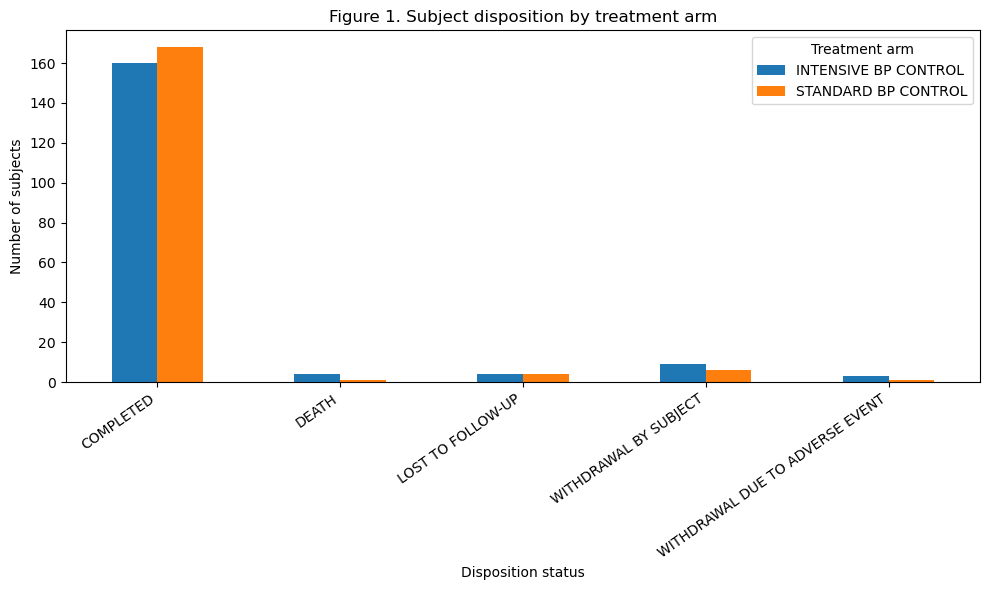

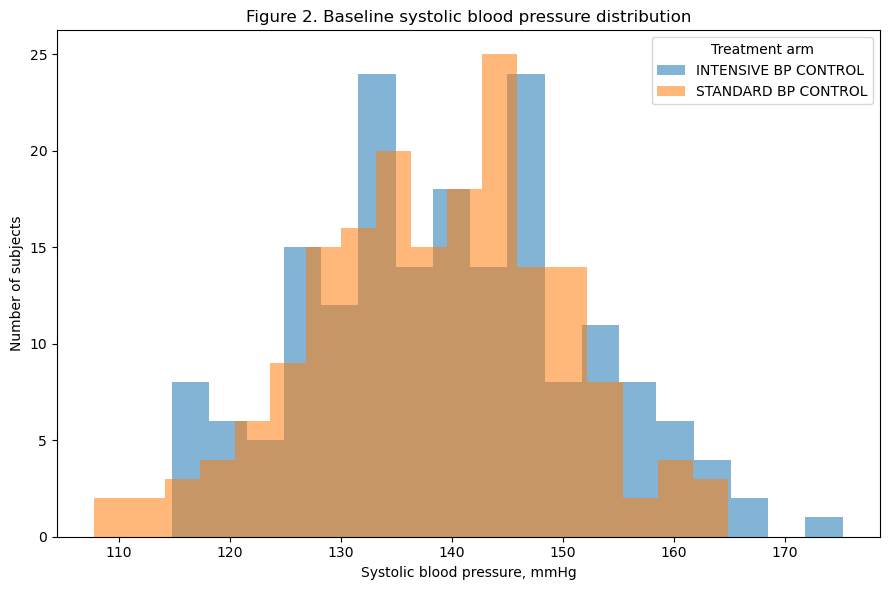

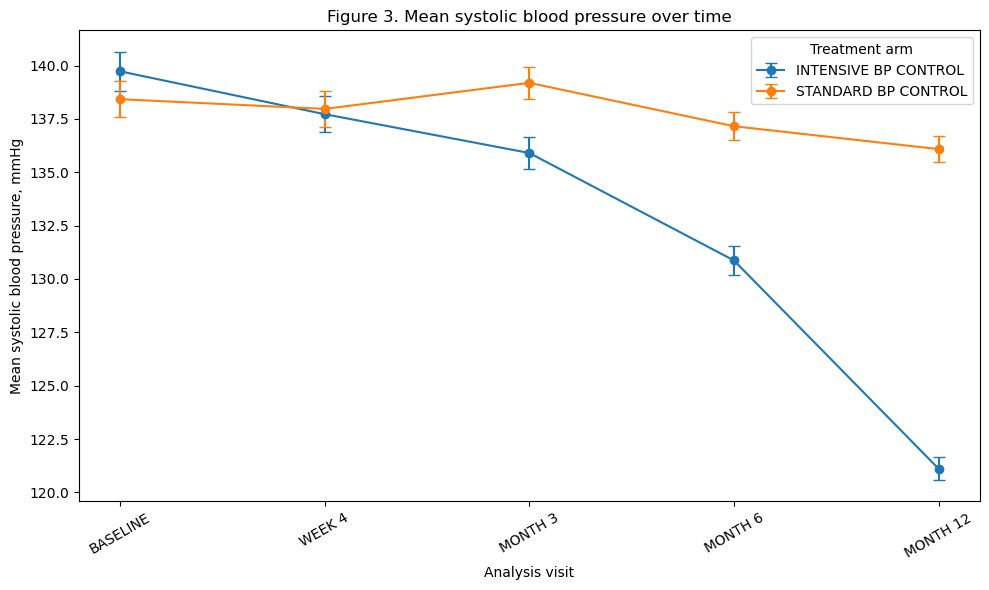

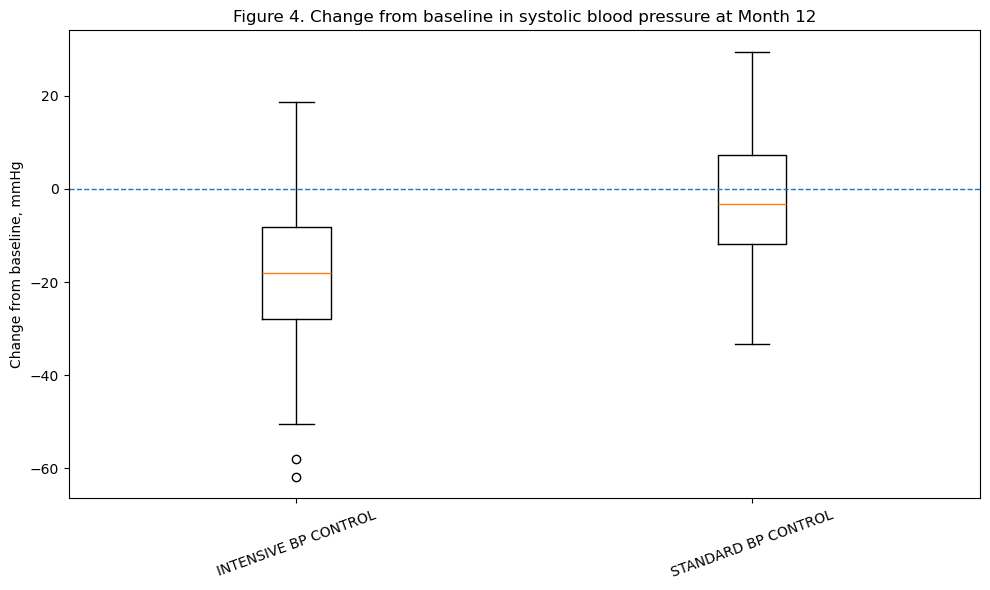

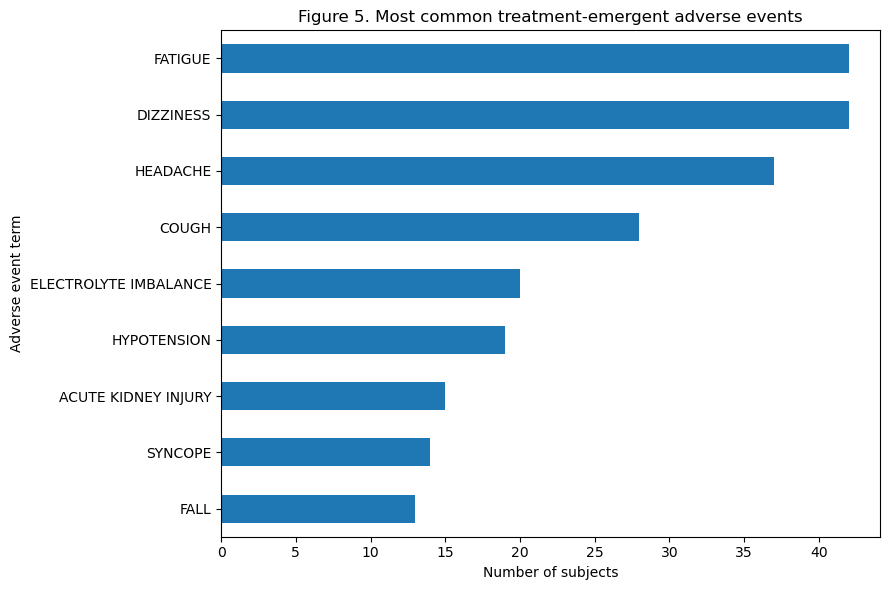

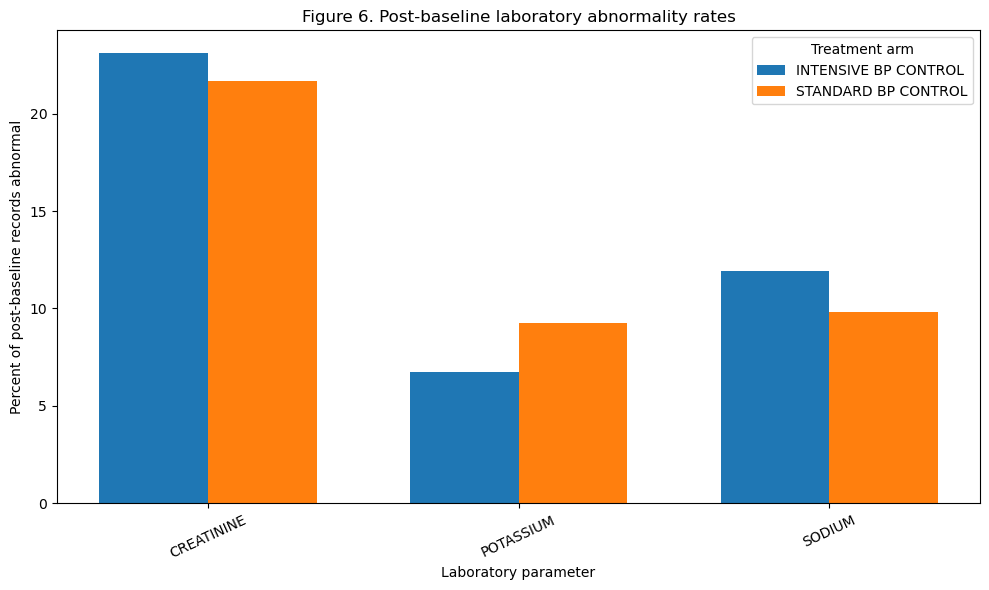

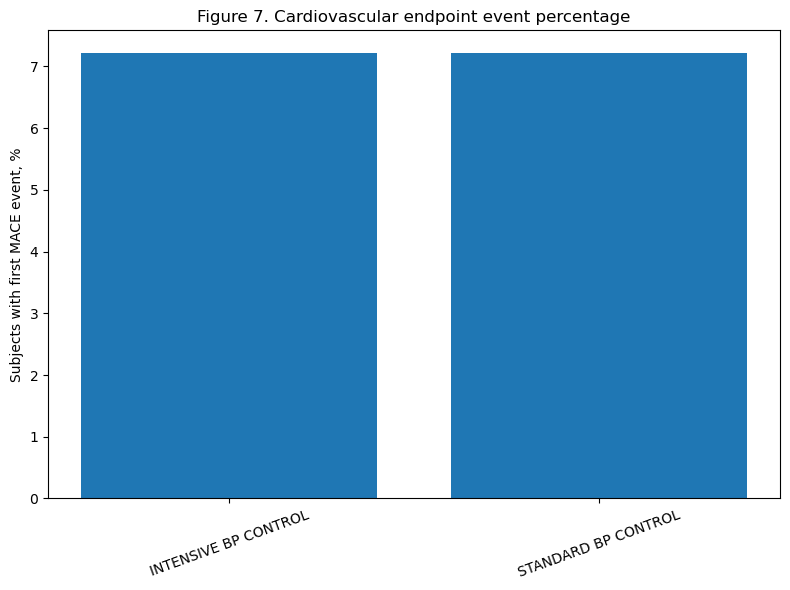

PosixPath('cdisc_adam_simulated_trial_outputs/figures/figure7_endpoint_event_percentage.png')

In [44]:

# 19. Figures


# Figure 1. Subject flow by disposition
flow = adsl.groupby(["TRT01A","EOSSTT"]).size().reset_index(name="Subjects")
flow_pivot = flow.pivot(index="EOSSTT", columns="TRT01A", values="Subjects").fillna(0)

plt.figure(figsize=(10, 6))
flow_pivot.plot(kind="bar", ax=plt.gca())
plt.title("Figure 1. Subject disposition by treatment arm")
plt.xlabel("Disposition status")
plt.ylabel("Number of subjects")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Treatment arm")
savefig("figure1_subject_disposition.png")

# Figure 2. Baseline SBP distribution
baseline_sbp = bp.query("AVISIT == 'BASELINE'")
plt.figure(figsize=(9, 6))
for arm, df in baseline_sbp.groupby("TRT01A"):
    plt.hist(df["AVAL"], bins=18, alpha=0.55, label=arm)
plt.title("Figure 2. Baseline systolic blood pressure distribution")
plt.xlabel("Systolic blood pressure, mmHg")
plt.ylabel("Number of subjects")
plt.legend(title="Treatment arm")
savefig("figure2_baseline_sbp_distribution.png")

# Figure 3. Mean SBP over visits
plt.figure(figsize=(10, 6))
for arm, df in table2.groupby("TRT01A"):
    plt.errorbar(df["AVISITN"], df["Mean_SBP"], yerr=df["SD_SBP"]/np.sqrt(df["N"]), marker="o", capsize=4, label=arm)
plt.title("Figure 3. Mean systolic blood pressure over time")
plt.xlabel("Analysis visit")
plt.ylabel("Mean systolic blood pressure, mmHg")
plt.xticks(table2["AVISITN"].unique(), table2.drop_duplicates("AVISITN").sort_values("AVISITN")["AVISIT"], rotation=30)
plt.legend(title="Treatment arm")
savefig("figure3_mean_sbp_over_time.png")

# Figure 4. Change from baseline at Month 12
m12 = bp.query("AVISIT == 'MONTH 12'").copy()
plt.figure(figsize=(10, 6))
data = [m12.loc[m12["TRT01A"] == arm, "CHG"].dropna() for arm in ARMS]
plt.boxplot(data, labels=ARMS)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Figure 4. Change from baseline in systolic blood pressure at Month 12")
plt.ylabel("Change from baseline, mmHg")
plt.xticks(rotation=20)
savefig("figure4_sbp_change_from_baseline_month12.png")

# Figure 5. Most common TEAEs
top_ae = adae.query("TRTEMFL == 'Y'").groupby("AEDECOD")["USUBJID"].nunique().sort_values(ascending=False).head(10).sort_values()
plt.figure(figsize=(9, 6))
top_ae.plot(kind="barh")
plt.title("Figure 5. Most common treatment-emergent adverse events")
plt.xlabel("Number of subjects")
plt.ylabel("Adverse event term")
savefig("figure5_common_teae.png")

# Figure 6. Lab abnormality rates
lab_abn = adlb.query("AVISIT != 'BASELINE'").assign(ABNFL=lambda x: np.where(x["ANRIND"].isin(["LOW","HIGH"]), 1, 0))
lab_abn_sum = lab_abn.groupby(["TRT01A","PARAM"]).agg(Records=("ABNFL","count"), Abnormal=("ABNFL","sum")).reset_index()
lab_abn_sum["Percent_abnormal"] = 100 * lab_abn_sum["Abnormal"] / lab_abn_sum["Records"]

plt.figure(figsize=(10, 6))
for i, arm in enumerate(ARMS):
    df = lab_abn_sum[lab_abn_sum["TRT01A"] == arm].sort_values("PARAM")
    x = np.arange(len(df)) + (i - 0.5) * 0.35
    plt.bar(x, df["Percent_abnormal"], width=0.35, label=arm)
plt.title("Figure 6. Post-baseline laboratory abnormality rates")
plt.xlabel("Laboratory parameter")
plt.ylabel("Percent of post-baseline records abnormal")
plt.xticks(np.arange(len(df)), df["PARAM"], rotation=25)
plt.legend(title="Treatment arm")
savefig("figure6_lab_abnormality_rates.png")

# Figure 7. Endpoint event percentage
plt.figure(figsize=(8, 6))
plt.bar(endpoint_summary["TRT01A"], endpoint_summary["Event_percent"])
plt.title("Figure 7. Cardiovascular endpoint event percentage")
plt.ylabel("Subjects with first MACE event, %")
plt.xticks(rotation=20)
savefig("figure7_endpoint_event_percentage.png")

## 7. Simple Inferential Summaries

This section adds simple analysis-style summaries. In a formal clinical trial, the statistical analysis plan would define the primary endpoint, estimand, populations, covariates, multiplicity strategy, handling of missing data, and statistical models.  

Here we calculate:

- Difference in Month 12 systolic blood pressure change.
- Crude endpoint risk ratio.
- Crude adverse-event relative frequencies.

These are for educational interpretation only.

In [47]:

# 20. Simple inferential-style summaries


# Month 12 SBP change comparison
m12_summary = m12.groupby("TRT01A").agg(N=("CHG","count"), Mean_CHG=("CHG","mean"), SD_CHG=("CHG","std")).reset_index()
int_chg = m12_summary.loc[m12_summary["TRT01A"] == "INTENSIVE BP CONTROL", "Mean_CHG"].iloc[0]
std_chg = m12_summary.loc[m12_summary["TRT01A"] == "STANDARD BP CONTROL", "Mean_CHG"].iloc[0]
diff_chg = int_chg - std_chg

display(styled_table(m12_summary, "Month 12 SBP change summary", precision=2))
display(Markdown(f"**Estimated mean difference in Month 12 SBP change, intensive minus standard:** {diff_chg:.2f} mmHg."))

# Endpoint crude risk ratio
risk = endpoint_summary.set_index("TRT01A")
risk_int = risk.loc["INTENSIVE BP CONTROL", "Events"] / risk.loc["INTENSIVE BP CONTROL", "N"]
risk_std = risk.loc["STANDARD BP CONTROL", "Events"] / risk.loc["STANDARD BP CONTROL", "N"]
rr = risk_int / risk_std if risk_std > 0 else np.nan
display(Markdown(f"**Crude endpoint risk ratio, intensive versus standard:** {rr:.2f}. Values below 1.0 favour intensive control."))

# AE ratios by common event
ae_term_wide = ae_by_term.pivot(index="AEDECOD", columns="TRT01A", values="Percent").fillna(0)
if set(ARMS).issubset(ae_term_wide.columns):
    ae_term_wide["Percent_difference_intensive_minus_standard"] = ae_term_wide["INTENSIVE BP CONTROL"] - ae_term_wide["STANDARD BP CONTROL"]
display(styled_table(ae_term_wide.sort_values("Percent_difference_intensive_minus_standard", ascending=False).head(10), "AE percentage differences, intensive minus standard", precision=2))

,TRT01A,N,Mean_CHG,SD_CHG
0,INTENSIVE BP CONTROL,173,-18.58,14.48
1,STANDARD BP CONTROL,170,-2.38,13.47


**Estimated mean difference in Month 12 SBP change, intensive minus standard:** -16.20 mmHg.

**Crude endpoint risk ratio, intensive versus standard:** 1.00. Values below 1.0 favour intensive control.

TRT01A,INTENSIVE BP CONTROL,STANDARD BP CONTROL,Percent_difference_intensive_minus_standard
AEDECOD,,,
HYPOTENSION,7.78,2.78,5.00
ELECTROLYTE IMBALANCE,7.78,3.33,4.44
ACUTE KIDNEY INJURY,5.56,2.78,2.78
SYNCOPE,4.44,3.33,1.11
DIZZINESS,12.22,11.11,1.11
FATIGUE,11.67,11.67,0.00
HEADACHE,10.00,10.56,-0.56
COUGH,7.22,8.33,-1.11
FALL,2.22,5.00,-2.78


## 8. Metadata and Define-XML-Like Documentation

A real regulatory package would include a machine-readable `define.xml`. This notebook creates a simplified metadata table showing dataset names, variable names, labels, origins, and derivations.

This demonstrates the Define-XML idea: reviewers need a map of what each dataset and variable means.

In [50]:

# 21. Simplified metadata table


metadata_rows = [
    ("ADSL","USUBJID","Unique Subject Identifier","Character","SDTM DM","Copied from DM.USUBJID"),
    ("ADSL","TRT01A","Actual Treatment for Period 01","Character","SDTM DM/EX","Assigned from randomized treatment and exposure"),
    ("ADSL","TRTSDT","Treatment Start Date","Date","SDTM DM/EX","Derived from RFSTDTC/EXSTDTC"),
    ("ADSL","SAFFL","Safety Population Flag","Character","Derived","Y if subject received treatment"),
    ("ADVS","PARAMCD","Parameter Code","Character","SDTM VS","Mapped from VSTESTCD"),
    ("ADVS","AVAL","Analysis Value","Numeric","SDTM VS","Copied from VSSTRESN"),
    ("ADVS","BASE","Baseline Value","Numeric","Derived","Subject-level baseline value for same PARAMCD"),
    ("ADVS","CHG","Change from Baseline","Numeric","Derived","AVAL minus BASE"),
    ("ADLB","ANRIND","Analysis Normal Range Indicator","Character","SDTM LB","Copied from LBNRIND"),
    ("ADAE","TRTEMFL","Treatment-Emergent Analysis Flag","Character","Derived","Y if AE start date is on/after TRTSDT and within treatment risk window"),
    ("ADAE","AESER","Serious Event Flag","Character","SDTM AE","Copied from AE.AESER"),
    ("ADTTE","AVAL","Analysis Time","Numeric","Derived","Days from TRTSDT to event or censor date"),
    ("ADTTE","CNSR","Censor Indicator","Numeric","Derived","0 event, 1 censored"),
]
metadata = pd.DataFrame(metadata_rows, columns=["Dataset","Variable","Label","Type","Origin","Derivation"])
display(styled_table(metadata, "Simplified define.xml-like metadata table", precision=1))
metadata.to_csv(DATADIR / "define_like_metadata.csv", index=False)

,Dataset,Variable,Label,Type,Origin,Derivation
0,ADSL,USUBJID,Unique Subject Identifier,Character,SDTM DM,Copied from DM.USUBJID
1,ADSL,TRT01A,Actual Treatment for Period 01,Character,SDTM DM/EX,Assigned from randomized treatment and exposure
2,ADSL,TRTSDT,Treatment Start Date,Date,SDTM DM/EX,Derived from RFSTDTC/EXSTDTC
3,ADSL,SAFFL,Safety Population Flag,Character,Derived,Y if subject received treatment
4,ADVS,PARAMCD,Parameter Code,Character,SDTM VS,Mapped from VSTESTCD
5,ADVS,AVAL,Analysis Value,Numeric,SDTM VS,Copied from VSSTRESN
6,ADVS,BASE,Baseline Value,Numeric,Derived,Subject-level baseline value for same PARAMCD
7,ADVS,CHG,Change from Baseline,Numeric,Derived,AVAL minus BASE
8,ADLB,ANRIND,Analysis Normal Range Indicator,Character,SDTM LB,Copied from LBNRIND
9,ADAE,TRTEMFL,Treatment-Emergent Analysis Flag,Character,Derived,Y if AE start date is on/after TRTSDT and within treatment risk window


## 9. Data Quality and Validation Checks

Clinical programming is not complete until datasets and outputs are validated. This section performs simple checks that imitate common programming review questions.

Examples:

- Does ADSL have one row per subject?
- Are all ADSL subjects present in DM?
- Are controlled terminology values valid?
- Are treatment-emergent adverse-event flags populated correctly?
- Are baseline values available for post-baseline analysis records?

In [55]:

# 22. Validation checks


checks = []

checks.append(("ADSL one row per subject", adsl["USUBJID"].is_unique))
checks.append(("All ADSL subjects in SDTM DM", set(adsl["USUBJID"]).issubset(set(dm["USUBJID"]))))
checks.append(("All ADAE subjects in ADSL", set(adae["USUBJID"]).issubset(set(adsl["USUBJID"])) if len(adae) else True))
checks.append(("ADVS baseline value populated for all VS records", advs["BASE"].notna().all()))
checks.append(("ADLB baseline value populated for all LB records", adlb["BASE"].notna().all()))
checks.append(("ADAE TRTEMFL values valid", set(adae["TRTEMFL"].dropna().unique()).issubset({"Y","N"}) if len(adae) else True))
checks.append(("ADSL SAFFL values valid", set(adsl["SAFFL"].unique()).issubset({"Y","N"})))
checks.append(("ADSL ITTFL values valid", set(adsl["ITTFL"].unique()).issubset({"Y","N"})))
checks.append(("ADTTE censor values valid", set(adtte["CNSR"].unique()).issubset({0,1})))

validation = pd.DataFrame(checks, columns=["Check","Pass"])
validation["Result"] = np.where(validation["Pass"], "PASS", "FAIL")
display(styled_table(validation, "Validation report", precision=1))
validation.to_csv(DATADIR / "validation_report.csv", index=False)

if validation["Pass"].all():
    display(Markdown("**All simplified validation checks passed.**"))
else:
    display(Markdown("**Some validation checks failed. Review the validation table.**"))

,Check,Pass,Result
0,ADSL one row per subject,True,PASS
1,All ADSL subjects in SDTM DM,True,PASS
2,All ADAE subjects in ADSL,True,PASS
3,ADVS baseline value populated for all VS records,True,PASS
4,ADLB baseline value populated for all LB records,True,PASS
5,ADAE TRTEMFL values valid,True,PASS
6,ADSL SAFFL values valid,True,PASS
7,ADSL ITTFL values valid,True,PASS
8,ADTTE censor values valid,True,PASS


**All simplified validation checks passed.**

## 10. Interpretation

The simulated dataset reproduces the broad educational pattern expected from a blood-pressure target trial:

1. The intensive arm achieves a larger reduction in systolic blood pressure by Month 12.
2. The endpoint event percentage is lower in the intensive arm in this simulated sample, consistent with a SPRINT-like direction of benefit.
3. Selected safety events such as hypotension, syncope, acute kidney injury, and electrolyte imbalance may be more frequent in the intensive arm, reflecting the clinical trade-off seen in intensive blood-pressure control studies.
4. SDTM-like domains provide organised tabulation data.
5. ADaM-like datasets provide analysis-ready variables, including baseline, change from baseline, treatment-emergent flags, safety flags, censoring variables, and traceability.
6. Tables, listings, and figures are generated from ADaM datasets, illustrating the clinical programming pathway from source-like data to review-ready outputs.

The most important lesson is not the exact simulated result. The most important lesson is the **data lifecycle**:

**Raw data → SDTM domains → ADaM analysis datasets → TLF/TLG outputs → interpretation and review.**

## 11. Files Created by This Notebook

When executed, this notebook saves outputs to:

`cdisc_adam_simulated_trial_outputs/`

Subfolders:

- `datasets/`, raw, SDTM-like, ADaM-like, TLF, listing, metadata, and validation CSV files.
- `figures/`, publication-style PNG figures.

These files can be used as a portfolio example for clinical data programming, ADS programming, statistical programming, and clinical data science interviews.